In [1]:
pip install mlxtend xgboost imblearn progressbar scanpy anndata

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
os.chdir("C:\\Users\\Le Tian\\Desktop\\Ensemble modeling\\comp-401")
#os.chdir("/Users/gaoletian/Desktop/Ensemble modeling/comp-401")
os.getcwd()

'C:\\Users\\Le Tian\\Desktop\\Ensemble modeling\\comp-401'

In [6]:
import anndata as ad
import pandas as pd
import scanpy as sc
import anndata as ad
from multi_omics_integration.func import *
from multi_omics_integration.classification_pipeline import *
from multi_omics_integration.processing import *
from multi_omics_integration.evaluation import *
import warnings
from pandas.errors import SettingWithCopyWarning
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import mannwhitneyu, wilcoxon
from sklearn.model_selection import RepeatedStratifiedKFold

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=ConvergenceWarning)

In [7]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

# RNA, miRNA, Methylation (No feature selection)

## Preprocessing

In [10]:
datasets = {'rna': '../Datasets/breast/RNASeq.csv',
            'mirna': '../Datasets/breast/miRNASeq.csv',
            'meth': '../Datasets/breast/Methylation.csv',}

labels = '../Datasets/breast/Clinical.csv'

In [11]:
subtypes = pd.read_csv(labels, index_col=0)

In [16]:
#separate for preprocessing
rna = pd.read_csv(datasets['rna'], index_col=0)
mirna = pd.read_csv(datasets['mirna'], index_col=0)
meth = pd.read_csv(datasets['meth'], index_col=0)

print('rna', rna.shape)
print('mirna', mirna.shape)
print('meth', meth.shape)

rna (430, 20155)
mirna (430, 823)
meth (430, 20106)


In [17]:
print("=== RNA Data ===")
print(rna.head())

print("\n=== miRNA Data ===")
print(mirna.head())

print("\n=== Methylation Data ===")
print(meth.head())

=== RNA Data ===
              A1BG_rna  A1CF_rna  A2BP1_rna  A2LD1_rna  A2ML1_rna  A2M_rna  \
SubjectID                                                                    
TCGA.A1.A0SF    8.3532       0.0     0.5144     7.3429     2.1464  13.9279   
TCGA.A1.A0SI    7.0163       0.0     0.6678     5.7506     2.5857  13.2612   
TCGA.A1.A0SN    6.4689       0.0     0.0000     6.1080     0.0000  13.4736   
TCGA.A1.A0SQ    9.8428       0.0     0.0000     5.5687     1.5932  13.4326   
TCGA.A2.A0CK    8.2170       0.0     0.4895     6.2324     1.1454  13.6076   

              A4GALT_rna  A4GNT_rna  AAA1_rna  AAAS_rna  ...  ZXDA_rna  \
SubjectID                                                ...             
TCGA.A1.A0SF      8.7887     0.8928       0.0    9.9751  ...    6.2310   
TCGA.A1.A0SI      8.0688     1.3054       0.0    9.2854  ...    6.1386   
TCGA.A1.A0SN      9.1908     0.0000       0.0    9.3137  ...    5.5001   
TCGA.A1.A0SQ      6.4749     0.0000       0.0    9.0821  ...    6.

### Removing low-variance + null features

In [19]:
# Methylation
from sklearn.feature_selection import VarianceThreshold

def remove_low_variance(X, threshold=0.05):
    # If the first column is IDs, move it to the index
    if X.columns[0].lower() in ['subjectid']:
        X = X.set_index(X.columns[0])

    selector = VarianceThreshold(threshold=threshold)
    X_filtered = selector.fit_transform(X)
    selected_features = X.columns[selector.get_support()]
    return pd.DataFrame(X_filtered, columns=selected_features, index=X.index)


meth_df = remove_low_variance(meth)

In [20]:
print(meth_df.shape)

(430, 754)


In [21]:
#transform into anndata
ad_rna = ad.AnnData(X=rna)
ad_mirna = ad.AnnData(X=mirna)

In [22]:
#preprocessing

# Normalize the data and log-transform
sc.pp.normalize_total(ad_rna)
sc.pp.log1p(ad_rna)  # Log-transform the data (log(x + 1))
sc.pp.highly_variable_genes(ad_rna, n_top_genes=2000)
ad_rna = ad_rna[:, ad_rna.var.highly_variable]  # Subset the data to highly variable genes
print(f"Number of highly variable genes (rna): {ad_rna.n_vars}")

Number of highly variable genes (rna): 2000


In [23]:
#similarly thing for mirna

# Normalize the data and log-transform
sc.pp.normalize_total(ad_mirna)
sc.pp.log1p(ad_mirna)  # Log-transform the data (log(x + 1))
sc.pp.highly_variable_genes(ad_mirna)
ad_mirna = ad_mirna[:, ad_mirna.var.highly_variable]  # Subset the data to highly variable genes
print(f"Number of highly variable genes (mirna): {ad_mirna.n_vars}")

Number of highly variable genes (mirna): 191


In [24]:
# convert to panda Dataframe
rna_df = pd.DataFrame(ad_rna.X.toarray() if hasattr(ad_rna.X, "toarray") else ad_rna.X,
                      index=ad_rna.obs_names,
                      columns=ad_rna.var_names)

mirna_df = pd.DataFrame(ad_mirna.X.toarray() if hasattr(ad_mirna.X, "toarray") else ad_mirna.X,
                        index=ad_mirna.obs_names,
                        columns=ad_mirna.var_names)

In [27]:
X = {}

X['rna'] = rna_df
X['rna'] = X['rna'].dropna(axis=1)
print('rna', X['rna'].shape)
X['mirna'] = mirna_df
X['mirna'] = X['mirna'].dropna(axis=1)
print('mirna', X['mirna'].shape)
X['meth'] = meth_df
X['meth'] = X['meth'].dropna(axis=1)
print('meth', X['meth'].shape)

rna (430, 2000)
mirna (430, 191)
meth (430, 705)


In [28]:
subtypes['PAM50'].value_counts()

PAM50
LumA     229
LumB     100
Basal     71
Her2      30
Name: count, dtype: int64

In [29]:
enc = LabelEncoder()
y = enc.fit_transform(subtypes['PAM50'])
enc.inverse_transform([0, 1, 2, 3])

array(['Basal', 'Her2', 'LumA', 'LumB'], dtype=object)

## Base Learners

In [40]:
from imblearn.ensemble import BalancedRandomForestClassifier

estimators = [
    ("logistic", make_pipeline(StandardScaler(), LogisticRegression(random_state=0, max_iter=1000, n_jobs=-1))),
    ("balanced_random_forest", make_pipeline(StandardScaler(), BalancedRandomForestClassifier(bootstrap=False, random_state=0, n_jobs=-1, sampling_strategy='all', replacement=True))),
    ("deep_nn", make_pipeline(StandardScaler(), MLPClassifier(random_state=0))),
    ("svc", make_pipeline(StandardScaler(), SVC(random_state=0, kernel='linear', max_iter=1000)))
]

estimator_names = [estimator[0] for estimator in estimators]

brca_scoring={'accuracy': 'accuracy', 'balanced_accuracy':'balanced_accuracy', 'f1': make_scorer(f1_score, average='weighted'), 'recall (Basal)': make_scorer(recall_multiclass, label=0), 'recall (Her2)': make_scorer(recall_multiclass, label=1), 'recall (LumA)': make_scorer(recall_multiclass, label=2), 'recall (LumB)': make_scorer(recall_multiclass, label=3)}

In [42]:
base_scores = {}
base_metrics_df = {}
base_metrics_df_train = {}

for modality in datasets:
    base_scores[modality], base_metrics_df[modality] = get_individual_scores(X[modality], y, estimators, scoring={"accuracy": "accuracy", "balanced_accuracy":"balanced_accuracy", "f1": make_scorer(f1_score, average='weighted'), 'recall (Basal)': make_scorer(recall_multiclass, label=0), 'recall (Her2)': make_scorer(recall_multiclass, label=1), 'recall (LumA)': make_scorer(recall_multiclass, label=2), 'recall (LumB)': make_scorer(recall_multiclass, label=3)})

 25%|██▌       | 1/4 [00:03<00:09,  3.10s/it]

logistic                  accuracy balanced_accuracy               f1   recall (Basal)  \
logistic  0.895 +/- 0.019   0.883 +/- 0.017  0.894 +/- 0.020  0.972 +/- 0.034   

            recall (Her2)    recall (LumA)    recall (LumB)  
logistic  0.867 +/- 0.067  0.935 +/- 0.036  0.760 +/- 0.097  


 50%|█████     | 2/4 [00:05<00:05,  2.63s/it]

balanced_random_forest                                accuracy balanced_accuracy               f1  \
balanced_random_forest  0.898 +/- 0.046   0.910 +/- 0.047  0.900 +/- 0.044   

                         recall (Basal)    recall (Her2)    recall (LumA)  \
balanced_random_forest  0.972 +/- 0.034  0.900 +/- 0.133  0.878 +/- 0.069   

                          recall (LumB)  
balanced_random_forest  0.890 +/- 0.066  


 75%|███████▌  | 3/4 [00:07<00:02,  2.57s/it]

...

 50%|█████     | 2/4 [00:00<00:00,  2.27it/s]

balanced_random_forest                                accuracy balanced_accuracy               f1  \
balanced_random_forest  0.784 +/- 0.051   0.781 +/- 0.071  0.786 +/- 0.053   

                         recall (Basal)    recall (Her2)    recall (LumA)  \
balanced_random_forest  0.972 +/- 0.034  0.700 +/- 0.194  0.790 +/- 0.048   

                          recall (LumB)  
balanced_random_forest  0.660 +/- 0.116  


100%|██████████| 4/4 [00:01<00:00,  2.26it/s]

deep_nn                 accuracy balanced_accuracy               f1   recall (Basal)  \
deep_nn  0.823 +/- 0.051   0.816 +/- 0.073  0.818 +/- 0.055  0.958 +/- 0.034   

           recall (Her2)    recall (LumA)    recall (LumB)  
deep_nn  0.833 +/- 0.149  0.882 +/- 0.061  0.590 +/- 0.150  
svc             accuracy balanced_accuracy               f1   recall (Basal)  \
svc  0.830 +/- 0.040   0.808 +/- 0.053  0.830 +/- 0.040  0.972 +/- 0.034   

       recall (Her2)    recall (LumA)    recall (LumB)  
svc  0.700 +/- 0.125  0.860 +/- 0.049  0.700 +/- 0.084  


100%|██████████| 4/4 [00:01<00:00,  2.15it/s]


In [43]:
display(base_metrics_df['rna']), display(base_metrics_df['mirna']), display(base_metrics_df['meth'])

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.895 +/- 0.019,0.883 +/- 0.017,0.894 +/- 0.020,0.972 +/- 0.034,0.867 +/- 0.067,0.935 +/- 0.036,0.760 +/- 0.097
balanced_random_forest,0.898 +/- 0.046,0.910 +/- 0.047,0.900 +/- 0.044,0.972 +/- 0.034,0.900 +/- 0.133,0.878 +/- 0.069,0.890 +/- 0.066
deep_nn,0.884 +/- 0.021,0.868 +/- 0.030,0.884 +/- 0.018,0.972 +/- 0.034,0.800 +/- 0.125,0.908 +/- 0.056,0.790 +/- 0.073
svc,0.891 +/- 0.006,0.894 +/- 0.013,0.890 +/- 0.006,0.972 +/- 0.034,0.933 +/- 0.082,0.921 +/- 0.038,0.750 +/- 0.071


,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.798 +/- 0.012,0.741 +/- 0.031,0.796 +/- 0.014,0.945 +/- 0.050,0.533 +/- 0.067,0.865 +/- 0.029,0.620 +/- 0.068
balanced_random_forest,0.786 +/- 0.022,0.752 +/- 0.036,0.787 +/- 0.023,0.959 +/- 0.054,0.567 +/- 0.170,0.812 +/- 0.044,0.670 +/- 0.129
deep_nn,0.779 +/- 0.028,0.720 +/- 0.045,0.774 +/- 0.034,0.902 +/- 0.056,0.567 +/- 0.082,0.873 +/- 0.035,0.540 +/- 0.124
svc,0.774 +/- 0.027,0.730 +/- 0.029,0.775 +/- 0.026,0.930 +/- 0.042,0.567 +/- 0.133,0.834 +/- 0.019,0.590 +/- 0.086


,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.833 +/- 0.050,0.791 +/- 0.057,0.830 +/- 0.053,0.958 +/- 0.034,0.633 +/- 0.067,0.882 +/- 0.045,0.690 +/- 0.156
balanced_random_forest,0.784 +/- 0.051,0.781 +/- 0.071,0.786 +/- 0.053,0.972 +/- 0.034,0.700 +/- 0.194,0.790 +/- 0.048,0.660 +/- 0.116
deep_nn,0.823 +/- 0.051,0.816 +/- 0.073,0.818 +/- 0.055,0.958 +/- 0.034,0.833 +/- 0.149,0.882 +/- 0.061,0.590 +/- 0.150
svc,0.830 +/- 0.040,0.808 +/- 0.053,0.830 +/- 0.040,0.972 +/- 0.034,0.700 +/- 0.125,0.860 +/- 0.049,0.700 +/- 0.084


(None, None, None)

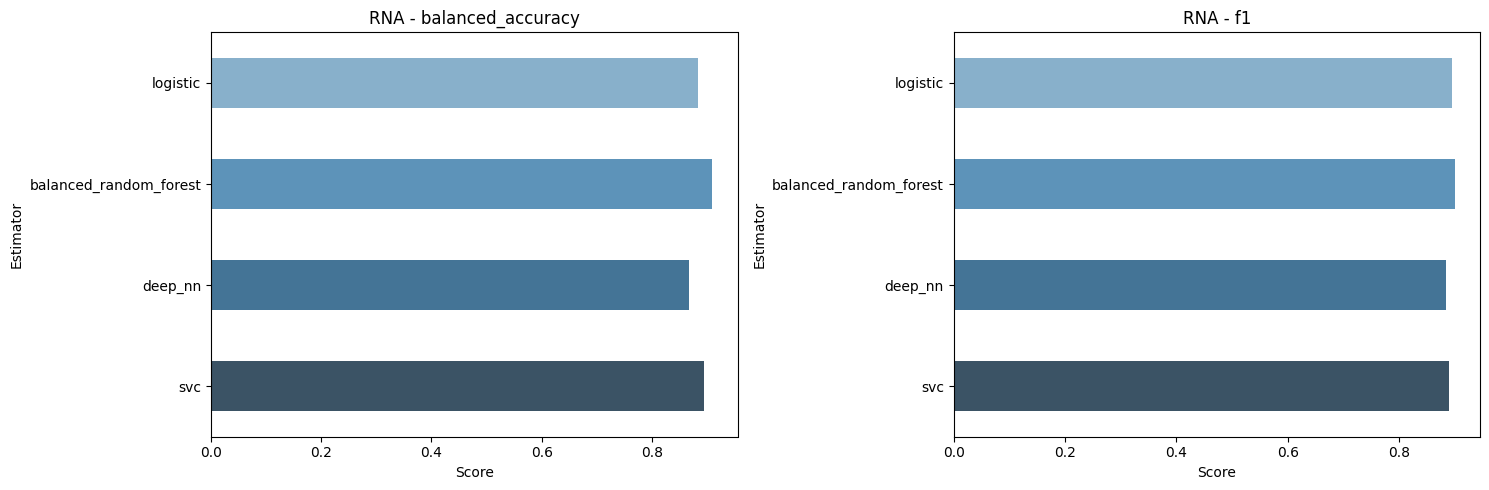

In [46]:
plot_bar_scores(estimator_names, base_scores['rna'], 'RNA', metrics=['balanced_accuracy', 'f1'])

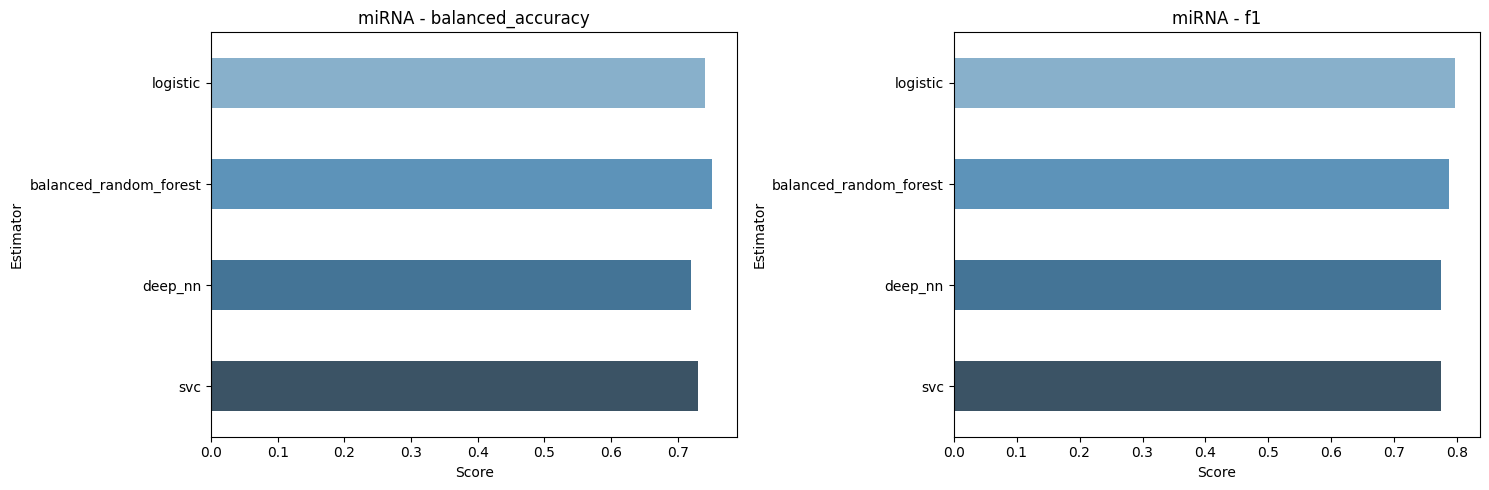

In [48]:
plot_bar_scores(estimator_names, base_scores['mirna'], 'miRNA', metrics=['balanced_accuracy', 'f1'])

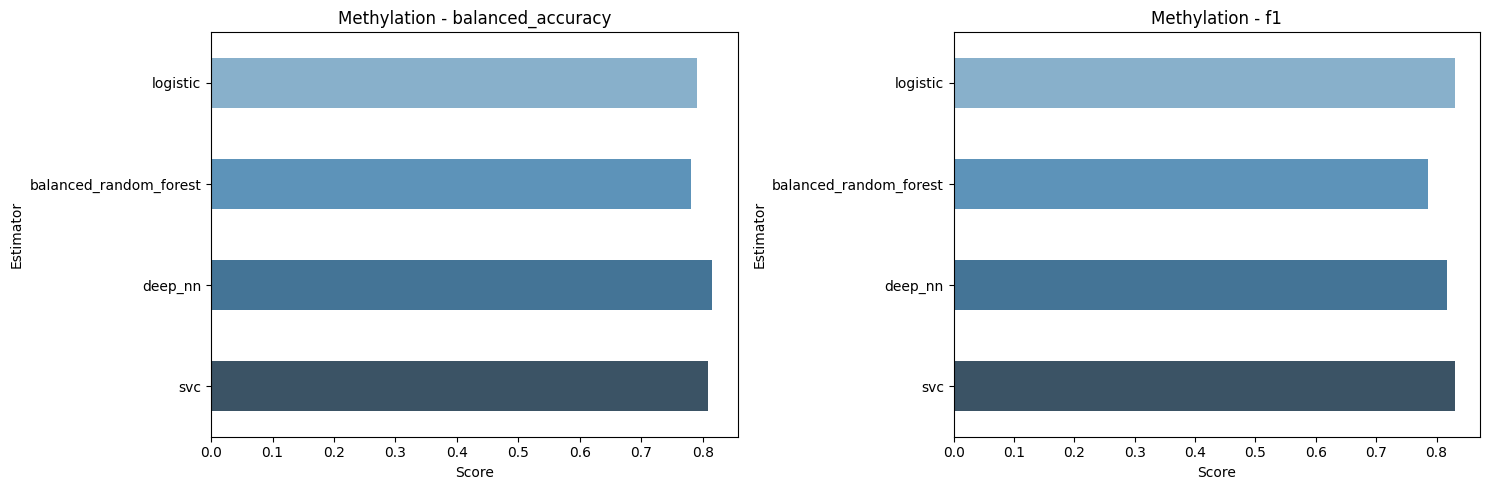

In [49]:
plot_bar_scores(estimator_names, base_scores['meth'], 'Methylation', metrics=['balanced_accuracy', 'f1'])

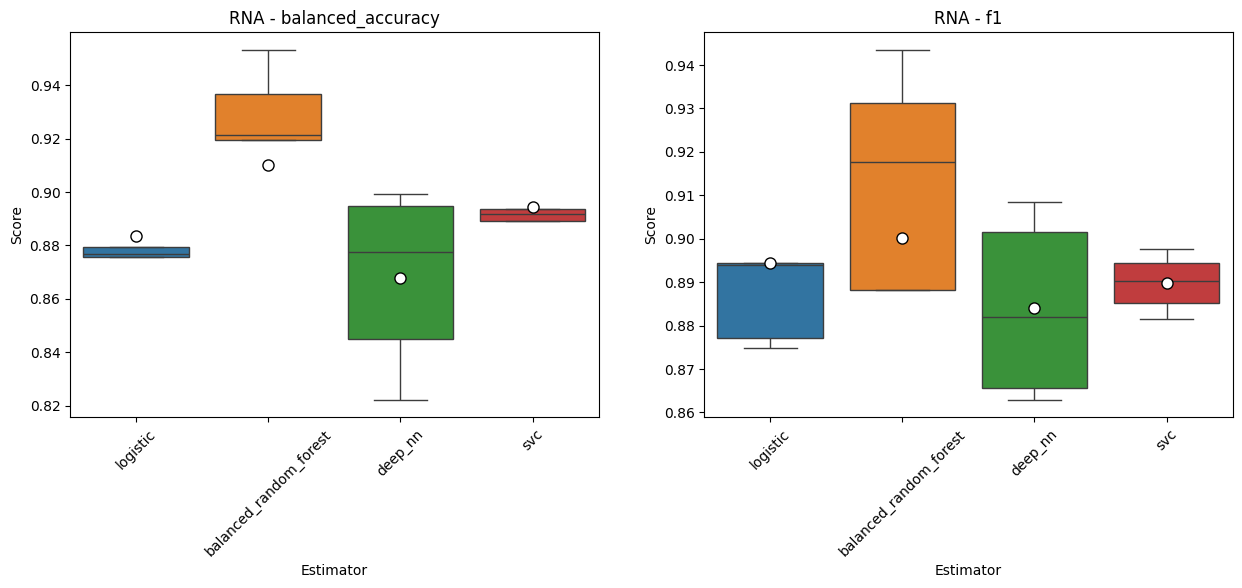

In [50]:
plot_box_scores(estimator_names, base_scores['rna'], 'RNA', metrics=['balanced_accuracy', 'f1'])

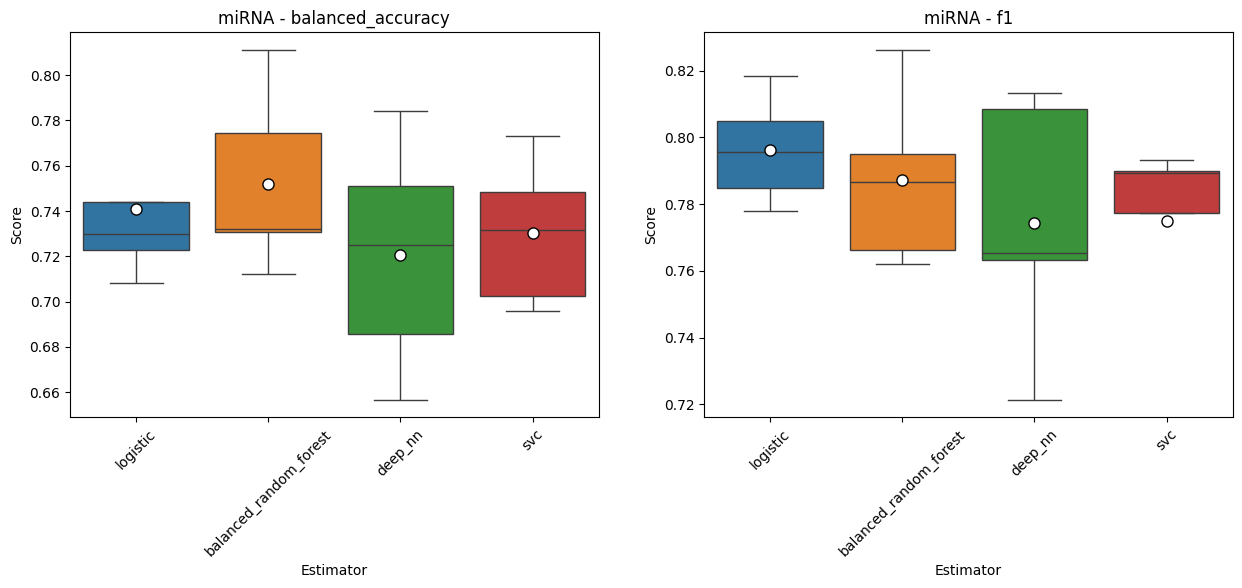

In [52]:
plot_box_scores(estimator_names, base_scores['mirna'], 'miRNA', metrics=['balanced_accuracy', 'f1'])

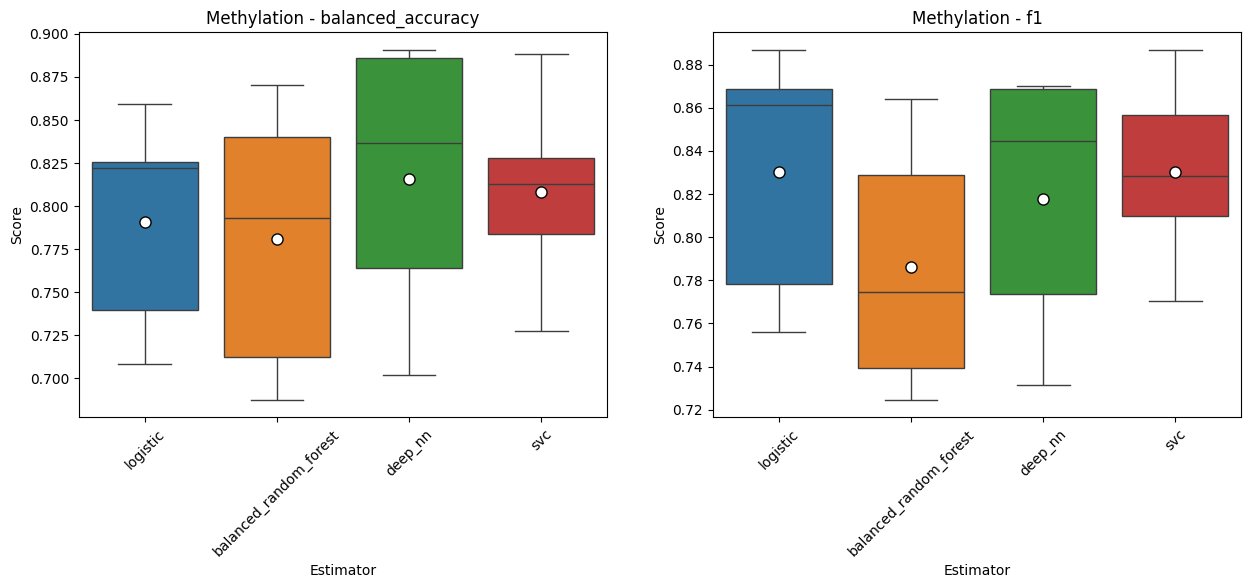

In [54]:
plot_box_scores(estimator_names, base_scores['meth'], 'Methylation', metrics=['balanced_accuracy', 'f1'])

### Testing significance tests

In [57]:
from scipy.stats import mannwhitneyu, wilcoxon
stat, p = mannwhitneyu(base_scores['rna'][0]['test_balanced_accuracy'], base_scores['rna'][3]['test_balanced_accuracy'])
print(p)
stat, p = wilcoxon(base_scores['rna'][0]['test_balanced_accuracy'], base_scores['rna'][3]['test_balanced_accuracy'])
print(p)

0.11607394330990008
0.27332167829229814


In [58]:
print(base_scores['mirna'][1])
print(base_scores['mirna'][2])

{'fit_time': array([0.23670387, 0.2352016 , 0.23470116, 0.23520207, 0.23320031]), 'score_time': array([0.02552128, 0.0260222 , 0.0260222 , 0.02702355, 0.02852488]), 'test_accuracy': array([0.76744186, 0.8255814 , 0.79069767, 0.77906977, 0.76744186]), 'test_balanced_accuracy': array([0.71195652, 0.77445652, 0.81112836, 0.73061594, 0.73194444]), 'test_f1': array([0.76211712, 0.82625656, 0.794926  , 0.7865488 , 0.76632837]), 'test_recall (Basal)': array([1.        , 1.        , 0.92857143, 1.        , 0.86666667]), 'test_recall (Her2)': array([0.5       , 0.5       , 0.83333333, 0.33333333, 0.66666667]), 'test_recall (LumA)': array([0.84782609, 0.84782609, 0.7826087 , 0.73913043, 0.84444444]), 'test_recall (LumB)': array([0.5 , 0.75, 0.7 , 0.85, 0.55])}
{'fit_time': array([0.28424406, 0.33078432, 0.35330343, 0.28874826, 0.29175162]), 'score_time': array([0.01151109, 0.01000881, 0.00850701, 0.02752328, 0.03352785]), 'test_accuracy': array([0.73255814, 0.80232558, 0.77906977, 0.81395349, 0.

In [60]:
stat, p = mannwhitneyu(base_scores['mirna'][1]['test_recall (Her2)'], base_scores['rna'][2]['test_recall (Her2)'])
print(p)

0.08567343955231686


In [61]:
from mlxtend.evaluate import paired_ttest_5x2cv

t, p = paired_ttest_5x2cv(estimator1=estimators[0][1],
                          estimator2=estimators[3][1],
                          X=X['rna'], y=y, scoring='balanced_accuracy', random_seed=1)

print('t statistic: %.3f' % t)
print('p value: %.3f' % p)

t statistic: -0.991
p value: 0.367


In [62]:
from mlxtend.evaluate import paired_ttest_5x2cv

t, p = paired_ttest_5x2cv(estimator1=estimators[1][1],
                          estimator2=estimators[2][1],
                          X=X['mirna'], y=y, scoring='balanced_accuracy', random_seed=2)

print('t statistic: %.3f' % t)
print('p value: %.3f' % p)

t statistic: 0.174
p value: 0.869


In [63]:
t, p = paired_ttest_5x2cv(estimator1=estimators[1][1],
                          estimator2=RandomForestClassifier(),
                          X=X['mirna'], y=y, scoring='balanced_accuracy', random_seed=2)

print('t statistic: %.3f' % t)
print('p value: %.3f' % p)

t statistic: 2.282
p value: 0.071


In [64]:
from sklearn.model_selection import RepeatedStratifiedKFold

results_model_1 = cross_val_score(estimators[1][1], X['mirna'], y, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=1), scoring='balanced_accuracy')
results_model_2 = cross_val_score(estimators[2][1], X['mirna'], y, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=1), scoring='balanced_accuracy')
results_model_3 = cross_val_score(RandomForestClassifier(), X['mirna'], y, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=1), scoring='balanced_accuracy')

In [66]:
print(results_model_1.mean())
print(results_model_2.mean())
print(results_model_3.mean())

0.7587767425810904
0.7079675638371291
0.6382694962042788


In [67]:
print(results_model_1.mean())
print(results_model_2.mean())
print(results_model_3.mean())

0.7587767425810904
0.7079675638371291
0.6382694962042788


In [68]:
from scipy.stats import wilcoxon
# Calculate p value
stat, p = wilcoxon(results_model_1, results_model_2, zero_method='zsplit')
print(p)
stat, p = wilcoxon(results_model_1, results_model_3, zero_method='zsplit')
print(p)

0.232421875
0.00390625


In [69]:
from scipy.stats import wilcoxon
# Calculate p value
stat, p = wilcoxon(results_model_1, results_model_2, zero_method='zsplit')
print(p)
stat, p = wilcoxon(results_model_1, results_model_3, zero_method='zsplit')
print(p)

0.232421875
0.00390625


In [70]:
results_model_1 = cross_val_score(estimators[1][1], X['mirna'], y, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=1), scoring='balanced_accuracy')
results_model_2 = cross_val_score(estimators[2][1], X['mirna'], y, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=2), scoring='balanced_accuracy')
results_model_3 = cross_val_score(RandomForestClassifier(), X['mirna'], y, cv=RepeatedStratifiedKFold(n_splits=2, n_repeats=5, random_state=3), scoring='balanced_accuracy')

In [73]:
from scipy.stats import mannwhitneyu

print(results_model_1.mean())
print(results_model_2.mean())
print(results_model_3.mean())

# Calculate p value
stat, p = mannwhitneyu(results_model_1, results_model_2)
print(p)
stat, p = mannwhitneyu(results_model_1, results_model_3)
print(p)

0.7677536231884058
0.7232260179434092
0.612748447204969
0.014494892347520633
0.00013574215557803193


In [74]:
results_model_1 = cross_val_score(estimators[1][1], X['mirna'], y, cv=StratifiedKFold(n_splits=20, shuffle=True, random_state=1), scoring='balanced_accuracy')
results_model_2 = cross_val_score(estimators[2][1], X['mirna'], y, cv=StratifiedKFold(n_splits=20, shuffle=True, random_state=1), scoring='balanced_accuracy')

In [75]:
results_model_3 = cross_val_score(RandomForestClassifier(), X['mirna'], y, cv=StratifiedKFold(n_splits=20, shuffle=True, random_state=1), scoring='balanced_accuracy')

In [77]:
print(results_model_1.mean())
print(results_model_2.mean())
print(results_model_3.mean())


0.7775757575757576
0.7153030303030304
0.6794507575757576


In [78]:
from scipy.stats import wilcoxon
# Calculate p value
stat, p = wilcoxon(results_model_1, results_model_2, zero_method='zsplit')
print(p)
stat, p = wilcoxon(results_model_1, results_model_3, zero_method='zsplit')
print(p)

0.10030984263941543
0.0014324188232421875


## Modality Ensembles

In [129]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingClassifier
from sklearn.calibration import CalibratedClassifierCV

class ModalityPipeline(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        estimator_list=None,
        feature_select=None,
        final_estimator=LogisticRegression(random_state=0, max_iter=1000, n_jobs=-1),
        cv=5,
        n_jobs=-1,
        stack_method="auto",
        calibration_cv=3,
        calibration_method="sigmoid",
    ):
        self.cv = cv
        self.estimator_list = estimator_list
        self.feature_select = feature_select
        self.final_estimator = final_estimator
        self.n_jobs = n_jobs
        self.stack_method = stack_method
        self.calibration_cv = calibration_cv
        self.calibration_method = calibration_method

    def _get_model(self):
        self.cv_ = StratifiedKFold(n_splits=self.cv, random_state=0, shuffle=True)

        # Wrap final estimator in a pipeline with imputer
        self.final_estimator_ = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("final", clone(self.final_estimator))
        ])

        # Calibrate each base estimator
        calibrated_estimators = []
        for name, est in self.estimator_list:
            calibrated = CalibratedClassifierCV(
                base_estimator=clone(est),
                cv=self.calibration_cv,
                method=self.calibration_method
            )
            calibrated_estimators.append((name, calibrated))

        # Create stacking classifier
        stacking = StackingClassifier(
            estimators=calibrated_estimators,
            final_estimator=self.final_estimator_,
            cv=self.cv_,
            stack_method=self.stack_method,
            n_jobs=self.n_jobs,
        )

        # Include feature selection if specified
        if self.feature_select is not None:
            model = Pipeline([
                ("feature_selection", self.feature_select),
                ("clf", stacking)
            ])
        else:
            model = stacking

        return model

    def fit(self, X, y):
        self.model_ = self._get_model()
        self.model_.fit(X, y)
        self.classes_ = self.model_.classes_

        # Try to extract coefficients if available
        try:
            self.coef_ = self.model_.final_estimator_.named_steps["final"].coef_
        except (AttributeError, KeyError):
            self.coef_ = None

        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


In [131]:
from sklearn.calibration import CalibratedClassifierCV
classifiers = {}

for modality in datasets:
    classifiers[modality] = ModalityPipeline(estimators, cv=3)

In [132]:
modality_metrics = pd.DataFrame()
scores = {}

for modality in tqdm(datasets):
    scores[modality], df = get_cross_metrics(classifiers[modality], X[modality], y, modality, scoring={"accuracy": "accuracy", "balanced_accuracy":"balanced_accuracy", "f1": make_scorer(f1_score, average='weighted'), 'recall (Basal)': make_scorer(recall_multiclass, label=0), 'recall (Her2)': make_scorer(recall_multiclass, label=1), 'recall (LumA)': make_scorer(recall_multiclass, label=2), 'recall (LumB)': make_scorer(recall_multiclass, label=3)})
    modality_metrics = pd.concat([modality_metrics, df])
    print(df)

 33%|███▎      | 1/3 [00:15<00:30, 15.42s/it]

            accuracy balanced_accuracy               f1   recall (Basal)  \
rna  0.921 +/- 0.019   0.925 +/- 0.012  0.922 +/- 0.018  0.972 +/- 0.034   

       recall (Her2)    recall (LumA)    recall (LumB)  
rna  0.933 +/- 0.082  0.926 +/- 0.049  0.870 +/- 0.040  


 67%|██████▋   | 2/3 [00:21<00:10, 10.01s/it]

              accuracy balanced_accuracy               f1   recall (Basal)  \
mirna  0.842 +/- 0.030   0.797 +/- 0.047  0.835 +/- 0.037  0.972 +/- 0.034   

         recall (Her2)    recall (LumA)    recall (LumB)  
mirna  0.667 +/- 0.149  0.917 +/- 0.035  0.630 +/- 0.172  


100%|██████████| 3/3 [00:30<00:00, 10.06s/it]

             accuracy balanced_accuracy               f1   recall (Basal)  \
meth  0.830 +/- 0.045   0.815 +/- 0.063  0.826 +/- 0.051  0.958 +/- 0.034   

        recall (Her2)    recall (LumA)    recall (LumB)  
meth  0.800 +/- 0.125  0.891 +/- 0.034  0.610 +/- 0.139  


### Scoring

In [135]:
modality_metrics

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
rna,0.921 +/- 0.019,0.925 +/- 0.012,0.922 +/- 0.018,0.972 +/- 0.034,0.933 +/- 0.082,0.926 +/- 0.049,0.870 +/- 0.040
mirna,0.842 +/- 0.030,0.797 +/- 0.047,0.835 +/- 0.037,0.972 +/- 0.034,0.667 +/- 0.149,0.917 +/- 0.035,0.630 +/- 0.172
meth,0.830 +/- 0.045,0.815 +/- 0.063,0.826 +/- 0.051,0.958 +/- 0.034,0.800 +/- 0.125,0.891 +/- 0.034,0.610 +/- 0.139


In [136]:
estimator_names = [
    "logistic",
    "balanced_random_forest",
    "deep_nn",
    "svc",
    "stacking"
]

all_scores = base_scores
all_scores['rna'].append(scores['rna'])
all_scores['mirna'].append(scores['mirna'])
all_scores['meth'].append(scores['meth'])

In [140]:
all_metrics = {}

# Joining metrics together for visualization
for modality in datasets:
    all_metrics[modality] = pd.concat([base_metrics_df[modality], modality_metrics.loc[[modality]]])
    all_metrics[modality].rename_axis(index={modality: 'stacking'}, inplace=True)

In [142]:
# Balanced random forest and standard scaler with deep neural network
display(all_metrics['rna'], all_metrics['mirna'], all_metrics['meth'])

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.895 +/- 0.019,0.883 +/- 0.017,0.894 +/- 0.020,0.972 +/- 0.034,0.867 +/- 0.067,0.935 +/- 0.036,0.760 +/- 0.097
balanced_random_forest,0.898 +/- 0.046,0.910 +/- 0.047,0.900 +/- 0.044,0.972 +/- 0.034,0.900 +/- 0.133,0.878 +/- 0.069,0.890 +/- 0.066
deep_nn,0.884 +/- 0.021,0.868 +/- 0.030,0.884 +/- 0.018,0.972 +/- 0.034,0.800 +/- 0.125,0.908 +/- 0.056,0.790 +/- 0.073
svc,0.891 +/- 0.006,0.894 +/- 0.013,0.890 +/- 0.006,0.972 +/- 0.034,0.933 +/- 0.082,0.921 +/- 0.038,0.750 +/- 0.071
rna,0.921 +/- 0.019,0.925 +/- 0.012,0.922 +/- 0.018,0.972 +/- 0.034,0.933 +/- 0.082,0.926 +/- 0.049,0.870 +/- 0.040


,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.798 +/- 0.012,0.741 +/- 0.031,0.796 +/- 0.014,0.945 +/- 0.050,0.533 +/- 0.067,0.865 +/- 0.029,0.620 +/- 0.068
balanced_random_forest,0.786 +/- 0.022,0.752 +/- 0.036,0.787 +/- 0.023,0.959 +/- 0.054,0.567 +/- 0.170,0.812 +/- 0.044,0.670 +/- 0.129
deep_nn,0.779 +/- 0.028,0.720 +/- 0.045,0.774 +/- 0.034,0.902 +/- 0.056,0.567 +/- 0.082,0.873 +/- 0.035,0.540 +/- 0.124
svc,0.774 +/- 0.027,0.730 +/- 0.029,0.775 +/- 0.026,0.930 +/- 0.042,0.567 +/- 0.133,0.834 +/- 0.019,0.590 +/- 0.086
mirna,0.842 +/- 0.030,0.797 +/- 0.047,0.835 +/- 0.037,0.972 +/- 0.034,0.667 +/- 0.149,0.917 +/- 0.035,0.630 +/- 0.172


,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.833 +/- 0.050,0.791 +/- 0.057,0.830 +/- 0.053,0.958 +/- 0.034,0.633 +/- 0.067,0.882 +/- 0.045,0.690 +/- 0.156
balanced_random_forest,0.784 +/- 0.051,0.781 +/- 0.071,0.786 +/- 0.053,0.972 +/- 0.034,0.700 +/- 0.194,0.790 +/- 0.048,0.660 +/- 0.116
deep_nn,0.823 +/- 0.051,0.816 +/- 0.073,0.818 +/- 0.055,0.958 +/- 0.034,0.833 +/- 0.149,0.882 +/- 0.061,0.590 +/- 0.150
svc,0.830 +/- 0.040,0.808 +/- 0.053,0.830 +/- 0.040,0.972 +/- 0.034,0.700 +/- 0.125,0.860 +/- 0.049,0.700 +/- 0.084
meth,0.830 +/- 0.045,0.815 +/- 0.063,0.826 +/- 0.051,0.958 +/- 0.034,0.800 +/- 0.125,0.891 +/- 0.034,0.610 +/- 0.139


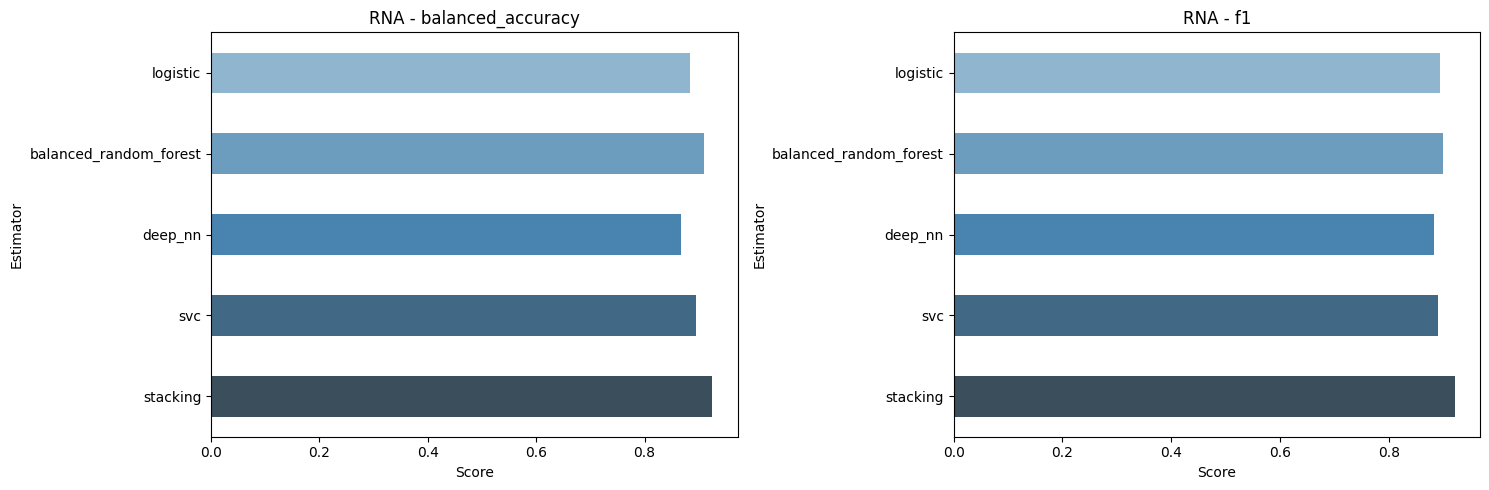

In [144]:
plot_bar_scores(estimator_names, base_scores['rna'], 'RNA', metrics=['balanced_accuracy', 'f1'])

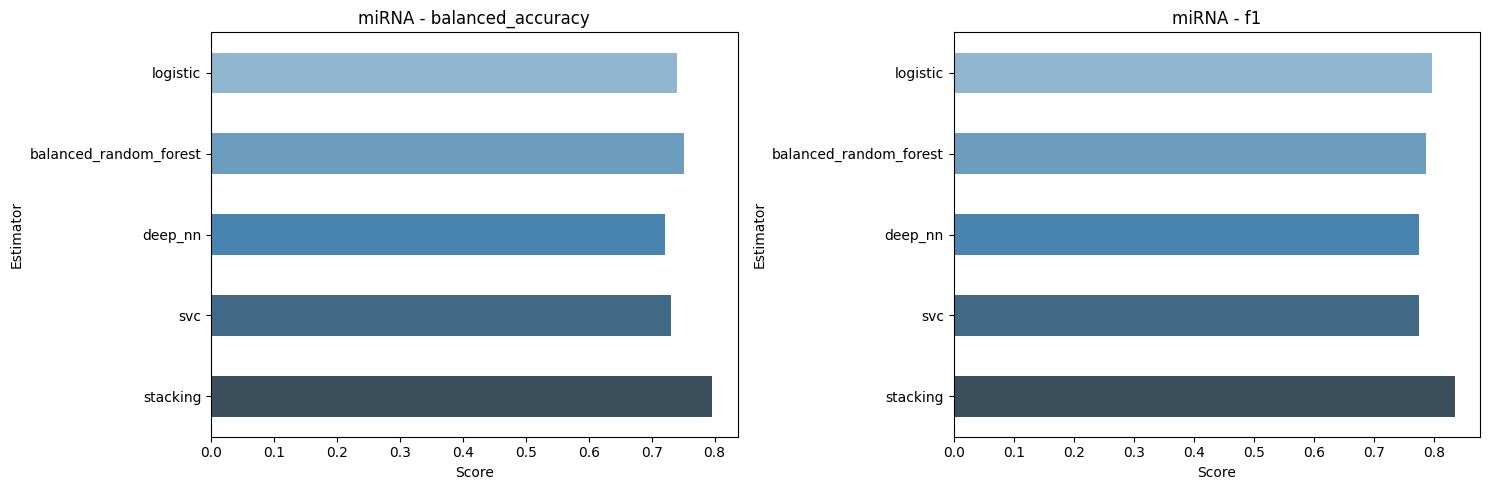

In [145]:
plot_bar_scores(estimator_names, base_scores['mirna'], 'miRNA', metrics=['balanced_accuracy', 'f1'])

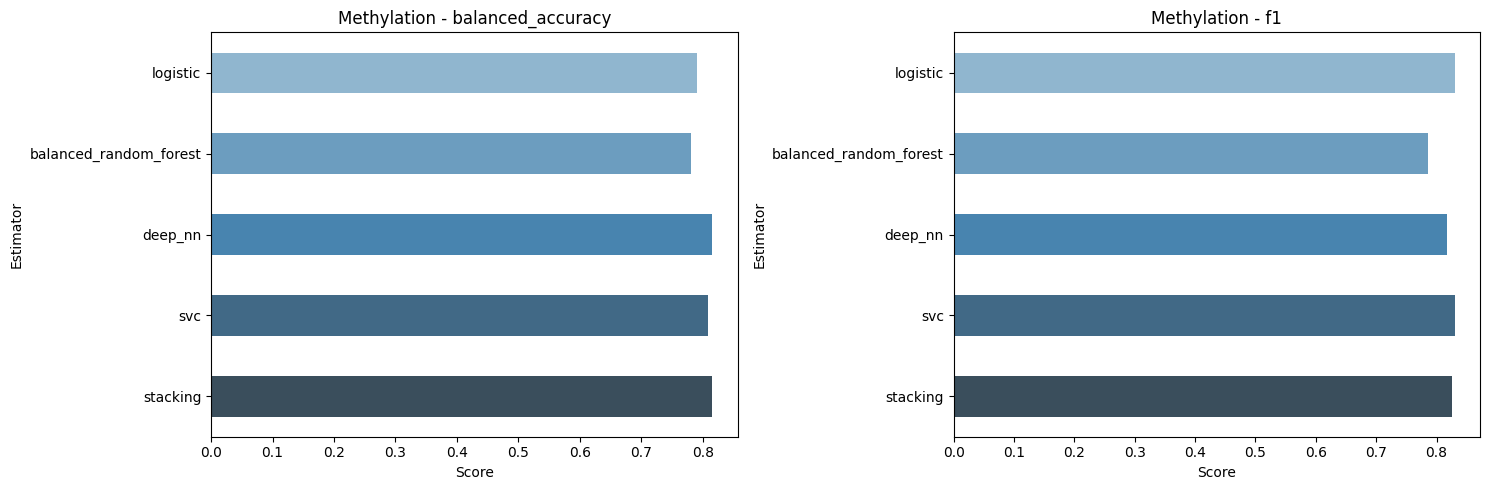

In [146]:
plot_bar_scores(estimator_names, base_scores['meth'], 'Methylation', metrics=['balanced_accuracy', 'f1'])

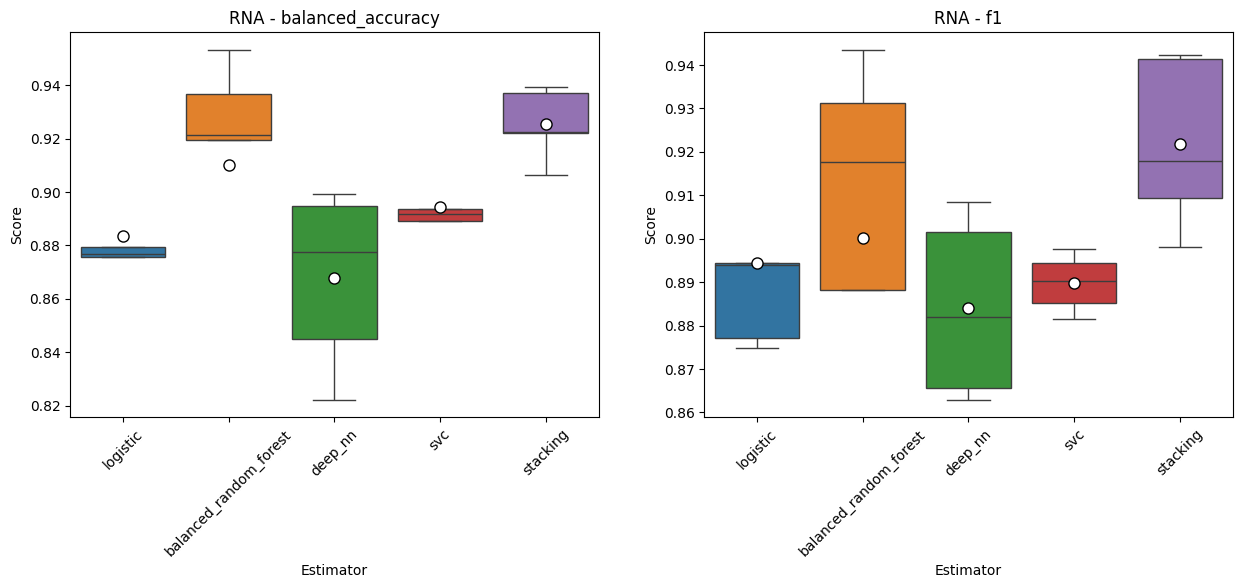

In [148]:
plot_box_scores(estimator_names, base_scores['rna'], 'RNA', metrics=['balanced_accuracy', 'f1'])

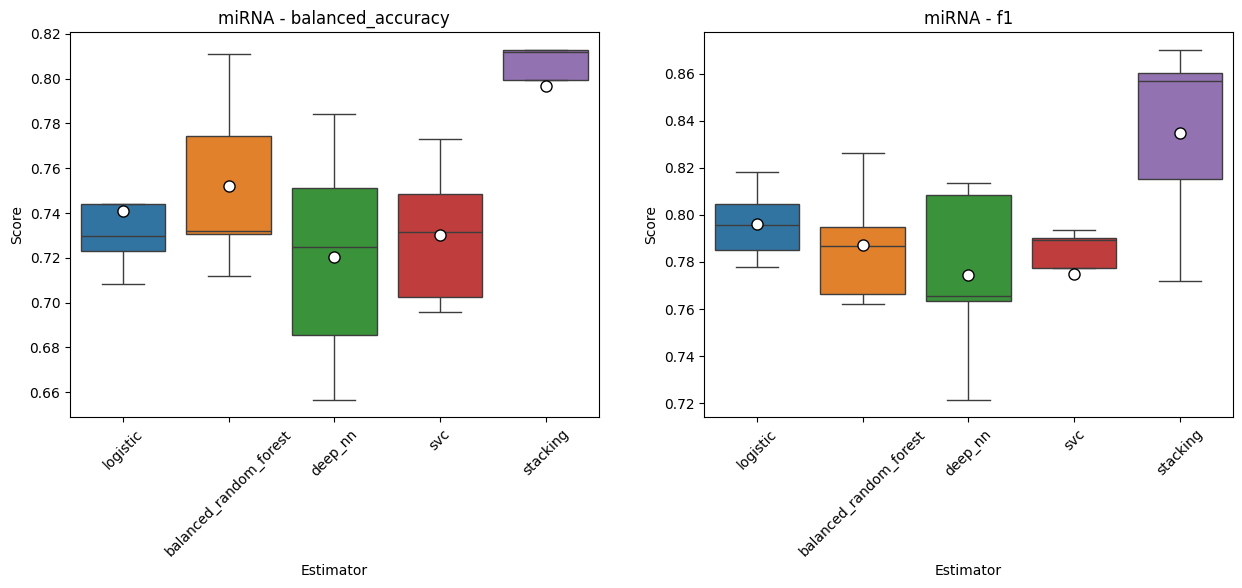

In [149]:
plot_box_scores(estimator_names, base_scores['mirna'], 'miRNA', metrics=['balanced_accuracy', 'f1'])

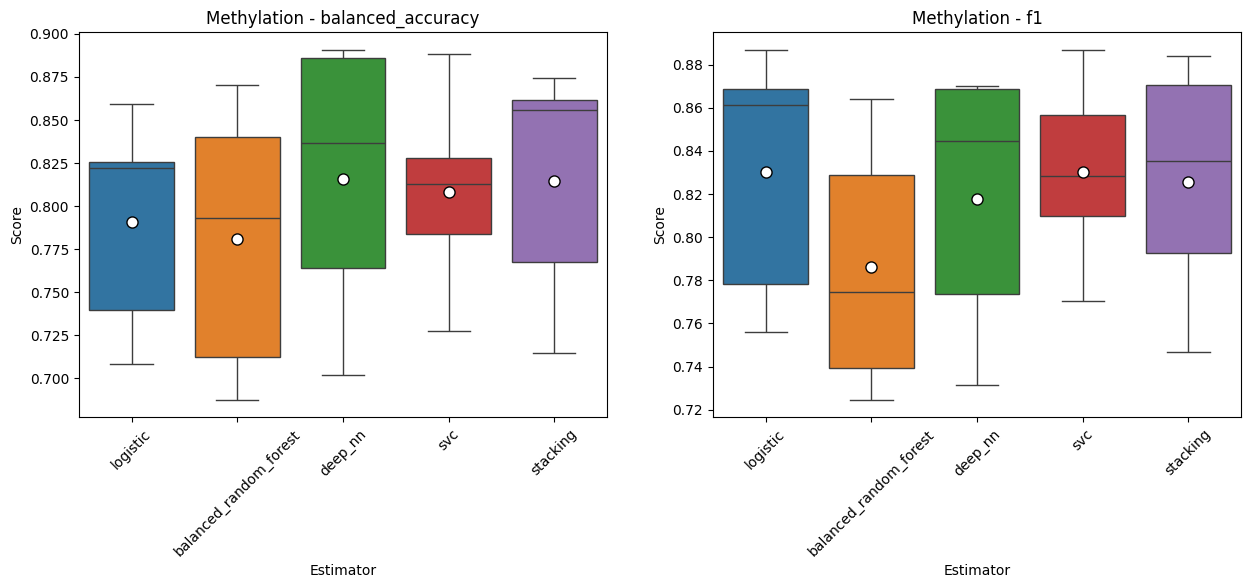

In [151]:
plot_box_scores(estimator_names, base_scores['meth'], 'Methylation', metrics=['balanced_accuracy', 'f1'])

## Multi Omics Integration Ensemble

### Ensemble Model as a Custom Classifier

In [320]:
from mlxtend.feature_selection import ColumnSelector

class MultiOmicsIntegrationClassifier(BaseEstimator, TransformerMixin):
    def __init__(self, estimator_dict=None, feature_select=None, final_estimator=LogisticRegression(random_state=0, n_jobs=-1), stack_method='auto', cv=5, n_jobs=-1):
        # calculating scores
        self.estimator_dict = estimator_dict
        self.feature_select = feature_select
        self.final_estimator = final_estimator
        self.stack_method = stack_method
        self.cv = cv
        self.n_jobs = n_jobs

    def _get_pipeline(self):
        self.classifiers_ = []
        self.cv_ = StratifiedKFold(n_splits=self.cv, random_state=0, shuffle=True)

        for dataset, columns in self.column_names_.items():
            stacking = Pipeline([('column_selector', ColumnSelector(cols=columns)), ('modality_clf', self.estimator_dict[dataset])])
            self.classifiers_.append((dataset, stacking))

        self.final_estimator_ = Pipeline([('imputer', SimpleImputer(strategy='median')), ('final_estimator', self.final_estimator)])
        stacking = StackingClassifier(estimators=self.classifiers_, final_estimator=self.final_estimator_, cv=self.cv_, stack_method=self.stack_method, n_jobs=self.n_jobs)

        return stacking

    def fit(self, X, y, column_names=None, **fit_params):

        self.column_names_ = column_names

        self.pipeline_ = self._get_pipeline()
        self.pipeline_.fit(X, y)

        return self

    def predict(self, X):
        return self.pipeline_.predict(X)

    def predict_proba(self, X):
        return self.pipeline_.predict_proba(X)

In [300]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV

# Dummy selector for column slicing
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X[self.cols]

class MultiOmicsIntegrationClassifier(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        estimator_dict=None,
        feature_select=None,
        final_estimator=LogisticRegression(random_state=0, n_jobs=-1),
        stack_method='auto',
        cv=5,
        n_jobs=-1,
        calibration_cv=5,
        calibration_method='sigmoid'
    ):
        self.estimator_dict = estimator_dict
        self.feature_select = feature_select
        self.final_estimator = final_estimator
        self.stack_method = stack_method
        self.cv = cv
        self.n_jobs = n_jobs
        self.calibration_cv = calibration_cv
        self.calibration_method = calibration_method

    def _get_pipeline(self):
        self.classifiers_ = []
        self.cv_ = StratifiedKFold(n_splits=self.cv, random_state=0, shuffle=True)

        for dataset, columns in self.column_names_.items():
            # Step 1: clone base estimator
            base_est = clone(self.estimator_dict[dataset])

            # Step 2: wrap base estimator in CalibratedClassifierCV
            calibrated_base_est = CalibratedClassifierCV(
                base_estimator=base_est,
                cv=self.calibration_cv,
                method=self.calibration_method
            )

            # Step 3: build modality pipeline: ColumnSelector → calibrated base model
            modality_pipeline = Pipeline([
                ('column_selector', ColumnSelector(cols=columns)),
                ('modality_model', calibrated_base_est)
            ])

            # Step 4: wrap the full modality pipeline in another CalibratedClassifierCV
            calibrated_modality_pipeline = CalibratedClassifierCV(
                base_estimator=modality_pipeline,
                cv=self.calibration_cv,
                method=self.calibration_method
            )

            self.classifiers_.append((dataset, calibrated_modality_pipeline))

        # Final estimator wrapped with imputation
        self.final_estimator_ = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('final_estimator', clone(self.final_estimator))
        ])

        # Final stacking classifier
        stacking = StackingClassifier(
            estimators=self.classifiers_,
            final_estimator=self.final_estimator_,
            cv=self.cv_,
            stack_method=self.stack_method,
            n_jobs=self.n_jobs
        )

        return stacking

    def fit(self, X, y, column_names=None, **fit_params):
        self.column_names_ = column_names
        self.pipeline_ = self._get_pipeline()
        self.pipeline_.fit(X, y, **fit_params)
        return self

    def predict(self, X):
        return self.pipeline_.predict(X)

    def predict_proba(self, X):
        return self.pipeline_.predict_proba(X)



In [322]:
classifiers = {}

for modality in datasets:
    classifiers[modality] = ModalityPipeline(estimators, cv=3)

In [324]:
column_names = {}
for key in X.keys():
    column_names[key] = X[key].columns

column_names_all = {}
column_names_rna_mirna = {}
column_names_mirna_meth = {}
column_names_rna_meth = {}


for key in X.keys():
    column_names_all[key] = X[key].columns
    
column_names_rna_mirna['rna'] = X['rna'].columns
column_names_rna_mirna['mirna'] = X['mirna'].columns

column_names_mirna_meth['mirna'] = X['mirna'].columns
column_names_mirna_meth['meth'] = X['meth'].columns

column_names_rna_meth['rna'] = X['rna'].columns
column_names_rna_meth['meth'] = X['meth'].columns

In [325]:
meta_ensembles = {}
meta_ensembles['rna + mirna + meth'] = MultiOmicsIntegrationClassifier(classifiers, cv=3)
meta_ensembles['mirna + meth'] = MultiOmicsIntegrationClassifier({key: classifiers[key] for key in ['mirna', 'meth']}, cv=3)
meta_ensembles['rna + mirna'] = MultiOmicsIntegrationClassifier({key: classifiers[key] for key in ['rna', 'mirna']}, cv=3)
meta_ensembles['rna + meth'] = MultiOmicsIntegrationClassifier({key: classifiers[key] for key in ['rna', 'meth']}, cv=3)

In [328]:
X_merged = {}
X_merged['rna + mirna + meth'] = pd.concat([X['rna'], X['mirna'], X['meth']], axis=1, join='inner')
X_merged['mirna + meth'] = pd.concat([X['mirna'], X['meth']], axis=1, join='inner')
X_merged['rna + mirna'] = pd.concat([X['rna'], X['mirna']], axis=1, join='inner')
X_merged['rna + meth'] = pd.concat([X['rna'], X['meth']], axis=1, join='inner')


In [329]:
integration_scores = {}
integration_metrics = {}

In [330]:
integration_scores['rna + mirna + meth'], integration_metrics['rna + mirna + meth'] = get_cross_metrics(meta_ensembles['rna + mirna + meth'], X_merged['rna + mirna + meth'], y, name='rna + mirna + meth', cv=5, verbose=2, scoring=brca_scoring, fit_params={'column_names': column_names_all})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:  1.4min remaining:   57.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.4min finished


In [331]:
integration_scores['mirna + meth'], integration_metrics['mirna + meth'] = get_cross_metrics(meta_ensembles['mirna + meth'], X_merged['mirna + meth'], y, name='mirna + meth', cv=5, verbose=2, scoring=brca_scoring, fit_params={'column_names': column_names_mirna_meth})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:   41.8s remaining:   27.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   42.2s finished


In [332]:
integration_scores['rna + mirna'], integration_metrics['rna + mirna'] = get_cross_metrics(meta_ensembles['rna + mirna'], X_merged['rna + mirna'], y, name='rna + mirna', cv=5, verbose=2, scoring=brca_scoring, fit_params={'column_names': column_names_rna_mirna})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:   56.4s remaining:   37.5s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   57.0s finished


In [333]:
integration_scores['rna + meth'], integration_metrics['rna + meth'] = get_cross_metrics(meta_ensembles['rna + meth'], X_merged['rna + meth'], y, name='rna + meth', cv=5, verbose=2, scoring=brca_scoring, fit_params={'column_names': column_names_rna_meth})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:  1.0min remaining:   41.3s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.0min finished


In [336]:
class_integration_stacking_metrics = pd.concat([modality_metrics] + list(integration_metrics.values()))
names = ['rna', 'mirna', 'meth', 'rna + mirna + meth', 'rna + mirna', 'rna + meth', 'mirna + meth']

class_integration = []
class_integration.append(scores['rna'])
class_integration.append(scores['mirna'])
class_integration.append(scores['meth'])

for name, value in integration_scores.items():
    class_integration.append(value)

In [337]:
class_integration_stacking_metrics

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
rna,0.921 +/- 0.019,0.925 +/- 0.012,0.922 +/- 0.018,0.972 +/- 0.034,0.933 +/- 0.082,0.926 +/- 0.049,0.870 +/- 0.040
mirna,0.842 +/- 0.030,0.797 +/- 0.047,0.835 +/- 0.037,0.972 +/- 0.034,0.667 +/- 0.149,0.917 +/- 0.035,0.630 +/- 0.172
meth,0.830 +/- 0.045,0.815 +/- 0.063,0.826 +/- 0.051,0.958 +/- 0.034,0.800 +/- 0.125,0.891 +/- 0.034,0.610 +/- 0.139
rna + mirna + meth,0.923 +/- 0.016,0.925 +/- 0.023,0.924 +/- 0.015,0.972 +/- 0.034,0.933 +/- 0.082,0.935 +/- 0.036,0.860 +/- 0.049
mirna + meth,0.849 +/- 0.007,0.827 +/- 0.027,0.846 +/- 0.009,0.972 +/- 0.034,0.767 +/- 0.133,0.900 +/- 0.040,0.670 +/- 0.103
rna + mirna,0.926 +/- 0.014,0.926 +/- 0.017,0.926 +/- 0.014,0.972 +/- 0.034,0.933 +/- 0.082,0.939 +/- 0.032,0.860 +/- 0.037
rna + meth,0.916 +/- 0.017,0.919 +/- 0.020,0.917 +/- 0.016,0.972 +/- 0.034,0.933 +/- 0.082,0.930 +/- 0.042,0.840 +/- 0.037


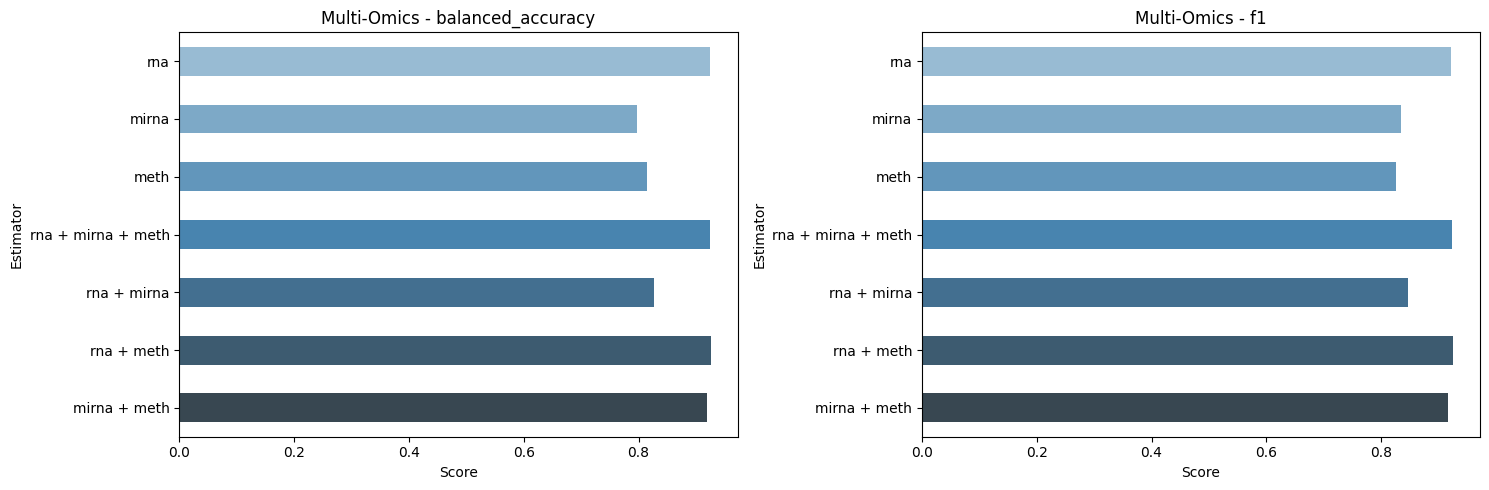

In [338]:
plot_bar_scores(names, class_integration, 'Multi-Omics', metrics=['balanced_accuracy', 'f1'])

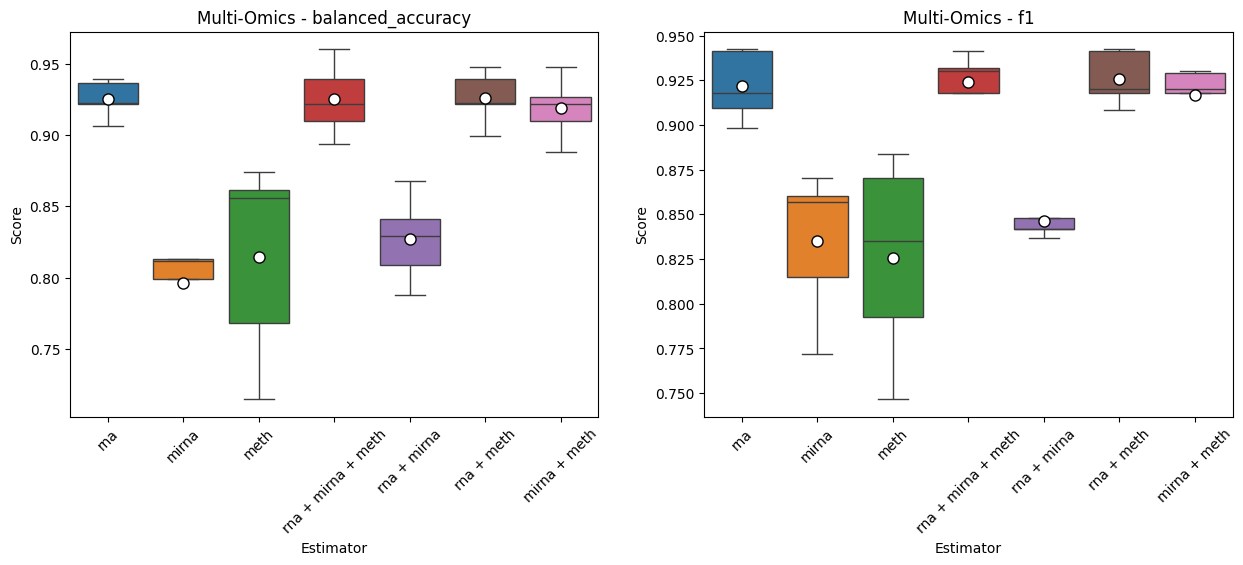

In [339]:
plot_box_scores(names, class_integration, 'Multi-Omics', metrics=['balanced_accuracy', 'f1'])

In [340]:
meta_ensembles['rna + mirna + meth'].fit(X_merged['rna + mirna + meth'], y, column_names=column_names_all)
meta_ensembles['rna + mirna + meth'].pipeline_

StackingClassifier(cv=StratifiedKFold(n_splits=3, random_state=0, shuffle=True),
                   estimators=[('rna',
                                Pipeline(steps=[('column_selector',
                                                 ColumnSelector(cols=Index(['A2ML1_rna', 'ABAT_rna', 'ABCA12_rna', 'ABCA13_rna', 'ABCA3_rna',
       'ABCA8_rna', 'ABCC11_rna', 'ABCC12_rna', 'ABCC13_rna', 'ABCC8_rna',
       ...
       'ZNF385B_rna', 'ZNF552_rna', 'ZNF679_rna', 'ZNF703_rna', 'ZNF716_rna...
                                                                                                    StandardScaler()),
                                                                                                   ('mlpclassifier',
                                                                                                    MLPClassifier(random_state=0))])),
                                                                                  ('svc',
                                                                                   Pipeline(steps=[('standardscaler',
                                                                                                    StandardScaler()),
                                                                                                   ('svc',
                                                                                                    SVC(kernel='linear',
                                                                                                        max_iter=1000,
                                                                                                        random_state=0))]))]))]))],
                   final_estimator=Pipeline(steps=[('imputer',
                                                    SimpleImputer(strategy='median')),
                                                   ('final_estimator',
                                                    LogisticRegression(n_jobs=-1,
                                                                       random_state=0))]),
                   n_jobs=-1)

## Statistical Significance

Now that we see the results, we want to check if the performance differences between our multi-omics ensemble models and the modality ensemble models are significant. We can employ the Wilcoxen test, using multiple replications of cross-validation to get scores.

### Wilcoxen

In [344]:
ensemble_results = {}
ensemble_metrics = {}

In [345]:
def wilcoxen_test(name_1, name_2, scores_1, scores_2):

    stat, p = wilcoxon(scores_1, scores_2, alternative='greater')

    df = pd.Series({'estimator_1': name_1, 'estimator_2': name_2, 'statistic': stat, 'p': p, 'significant': p <= 0.05})

    return pd.DataFrame(df).T

In [346]:
ensemble_results = {}
ensemble_metrics = {}

In [347]:
ensemble_results['mirna + meth'], ensemble_metrics['mirna + meth'] = get_cross_metrics(meta_ensembles['mirna + meth'], X_merged['mirna + meth'], y, name='mirna + meth', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring, fit_params={'column_names': {key: column_names[key] for key in ['mirna', 'meth']}})
ensemble_results['meth'], ensemble_metrics['meth'] = get_cross_metrics(classifiers['meth'], X['meth'], y, name='meth', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring)
ensemble_results['mirna'], ensemble_metrics['mirna'] = get_cross_metrics(classifiers['mirna'], X['mirna'], y, name='mirna', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring)


In [348]:
ensemble_results['rna + mirna + meth'], ensemble_metrics['rna + mirna + meth'] = get_cross_metrics(meta_ensembles['rna + mirna + meth'], X_merged['rna + mirna + meth'], y, name='rna + mirna + meth', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring, fit_params={'column_names': column_names})
ensemble_results['rna'], ensemble_metrics['rna'] = get_cross_metrics(classifiers['rna'], X['rna'], y, name='rna', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring)

In [373]:
ensemble_results['rna + mirna'], ensemble_metrics['rna + mirna'] = get_cross_metrics(meta_ensembles['rna + mirna'], X_merged['rna + mirna'], y, name='rna + mirna', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring, fit_params={'column_names': {key: column_names[key] for key in ['rna', 'mirna']}})
ensemble_results['rna + meth'], ensemble_metrics['rna + meth'] = get_cross_metrics(meta_ensembles['rna + meth'], X_merged['rna + meth'], y, name='rna + meth', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring, fit_params={'column_names': {key: column_names[key] for key in ['rna', 'meth']}})


In [375]:
# Picking models we want to compare performances for
compare = [
    ('mirna + meth', 'meth'),
    ('mirna + meth', 'mirna'),
    ('rna + mirna' , 'rna'),
    ('rna + mirna' , 'mirna'),
    ('rna + meth' , 'rna'),
    ('rna + meth' , 'meth'),
    ('rna + mirna + meth', 'rna')
]

In [377]:
wilcoxen_results = {}
metrics = ['balanced_accuracy', 'f1']

for metric in metrics:
    wilcoxen_results[metric] = pd.DataFrame()
    for est1, est2 in compare:
        df = wilcoxen_test(est1, est2, ensemble_results[est1]['test_' + metric], ensemble_results[est2]['test_' + metric])
        wilcoxen_results[metric] = pd.concat([wilcoxen_results[metric], df])


In [379]:
display(wilcoxen_results['balanced_accuracy'], wilcoxen_results['f1'])

,estimator_1,estimator_2,statistic,p,significant
0,mirna + meth,meth,87.0,0.067688,False
0,mirna + meth,mirna,102.0,0.000941,True
0,rna + mirna,rna,45.0,0.318806,False
0,rna + mirna,mirna,120.0,0.000031,True
0,rna + meth,rna,10.0,0.750903,False
0,rna + meth,meth,119.0,0.000061,True
0,rna + mirna + meth,rna,31.0,0.570568,False


,estimator_1,estimator_2,statistic,p,significant
0,mirna + meth,meth,96.0,0.02063,True
0,mirna + meth,mirna,98.0,0.002143,True
0,rna + mirna,rna,51.0,0.173261,False
0,rna + mirna,mirna,120.0,0.000031,True
0,rna + meth,rna,13.0,0.75808,False
0,rna + meth,meth,118.0,0.000092,True
0,rna + mirna + meth,rna,38.0,0.531264,False


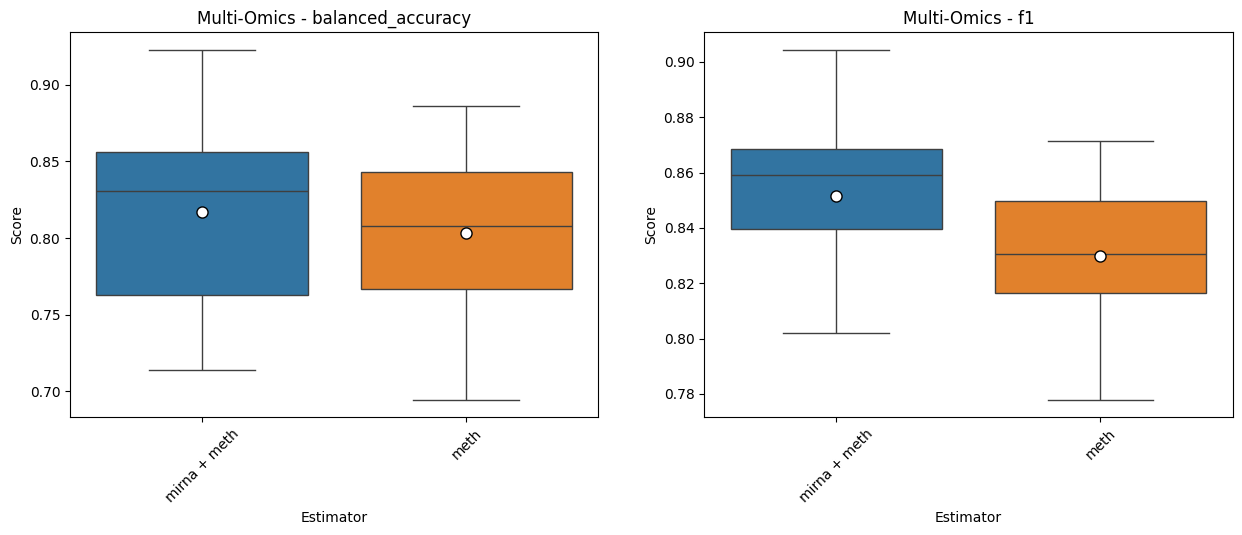

In [352]:
plot_box_scores(['mirna + meth', 'meth'], [ensemble_results['mirna + meth'], ensemble_results['meth']], 'Multi-Omics', metrics=['balanced_accuracy', 'f1'])

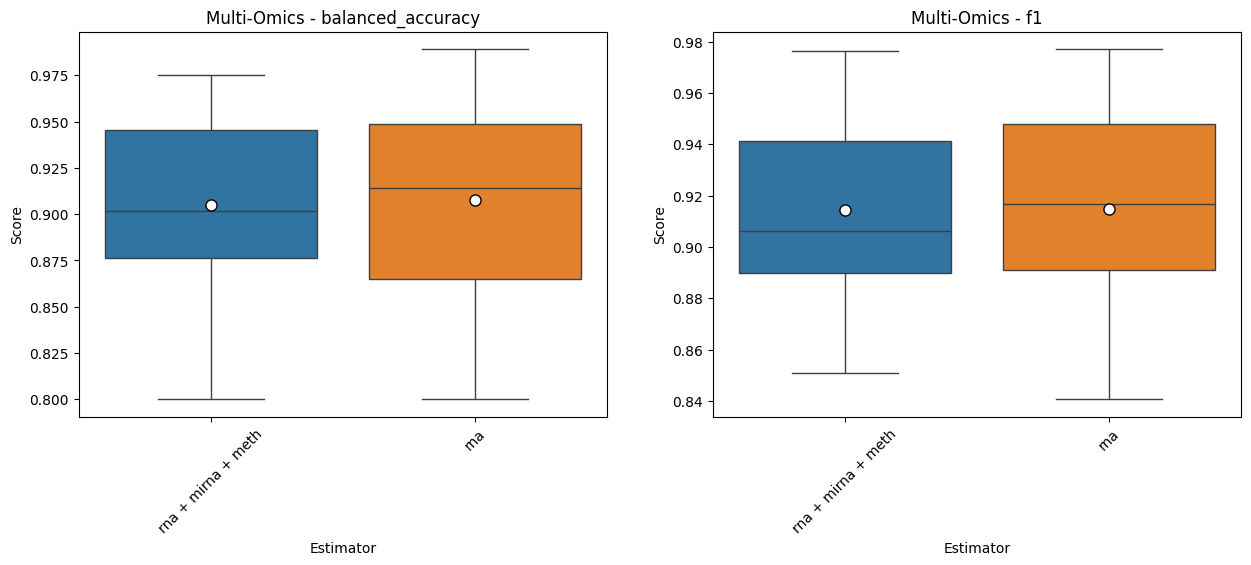

In [353]:
plot_box_scores(['rna + mirna + meth', 'rna'], [ensemble_results['rna + mirna + meth'], ensemble_results['rna']], 'Multi-Omics', metrics=['balanced_accuracy', 'f1'])

In [354]:
import json
# Convert and write JSON object to file
with open("notebooks_new/results/brca/brca_5x3_results.json", "w") as outfile:
    json.dump(ensemble_results, outfile, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

### Paired t-test

In [356]:
from mlxtend.evaluate import paired_ttest_5x2cv

def p_value(estimator_1, estimator_2, X_1, X_2, y, scoring=make_scorer(f1_score, average='weighted'), random_seed=0, fit_params_1=None, fit_params_2=None):
    t, p = paired_ttest_5x2cv_custom(estimator_1[1], estimator_2[1], X_1, X_2, y, scoring=scoring, random_seed=random_seed, fit_params_1=fit_params_1, fit_params_2=fit_params_2)

    significant = p <= 0.05
    results = pd.DataFrame({'estimator_1': estimator_1[0], 'estimator_2': estimator_2[0], 'p': p, 'significant': significant}, index=[0])

    return results

In [357]:
import numpy as np

In [358]:
p_value_mirna_meth = p_value(('mirna + meth', meta_ensembles['mirna + meth']), ('mirna', classifiers['mirna']),  pd.concat([X['mirna'], X['meth']], axis=1, join='inner'), X['mirna'], y, fit_params_1={'column_names': {'mirna': X['mirna'].columns, 'meth': X['meth'].columns}})

NameError: name 'np' is not defined

## Modality Ensembles

In [ ]:
classifiers = {}

for modality in datasets:
    classifiers[modality] = ModalityPipeline(estimators, cv=3)

In [ ]:
modality_metrics = pd.DataFrame()
scores = {}

for modality in tqdm(datasets):
    scores[modality], df = get_cross_metrics(classifiers[modality], X[modality], y, modality, scoring=brca_scoring)
    modality_metrics = pd.concat([modality_metrics, df])

In [ ]:
modality_metrics = pd.DataFrame()
scores = {}

for modality in tqdm(datasets):
    scores[modality], df = get_cross_metrics(classifiers[modality], X[modality], y, modality, scoring=brca_scoring, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1))
    modality_metrics = pd.concat([modality_metrics, df])

### Scoring

In [ ]:
modality_metrics

In [ ]:
# 5x3
modality_metrics

In [ ]:
import json

In [ ]:
# Convert and write JSON object to file
with open("notebooks_new/results/brca/brca_modality_results.json", "w") as outfile:
    json.dump(scores, outfile, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

In [1225]:
estimator_names = [
    "logistic",
    "balanced_random_forest",
    "deep_nn",
    "svc",
    "stacking"
]

all_scores = {}

for modality in base_scores:
    all_scores[modality] = {}
    for i in range(len(base_scores[modality])):
        all_scores[modality][estimator_names[i]] = base_scores[modality][i]

    all_scores[modality]['stacking'] = scores[modality]

In [1228]:
# Convert and write JSON object to file
with open("notebooks_new/results/brca/brca_base_learner_modality_results.json", "w") as outfile:
    json.dump(all_scores, outfile, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

In [1230]:
# Run this if continuing an already saved run:
with open("notebooks_new/results/brca/brca_modality_results.json",'r+') as file:
    modality_scores = json.load(file)
    modality_metrics = pd.DataFrame()

    for model in modality_scores:
      metrics = {}

      for scorer in brca_scoring:
        metrics[scorer] = []

      for scorer in brca_scoring:
          metrics[scorer].append(
              "%0.3f +/- %0.3f"
              % (np.mean(modality_scores[model]["test_%s" % scorer]), np.std(modality_scores[model]["test_%s" % scorer]))
      )
      modality_metrics = pd.concat([modality_metrics, pd.DataFrame(metrics, index=[model])])

In [1232]:
all_metrics = {}

# Joining metrics together for visualization
for modality in datasets:
    all_metrics[modality] = pd.concat([base_metrics_df[modality], modality_metrics.loc[[modality]]])
    all_metrics[modality].rename_axis(index={modality: 'stacking'}, inplace=True)

In [1234]:
# Balanced random forest and standard scaler with deep neural network
display(all_metrics['rna'], all_metrics['mirna'], all_metrics['meth'])

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.902 +/- 0.016,0.888 +/- 0.015,0.901 +/- 0.017,0.972 +/- 0.034,0.867 +/- 0.067,0.943 +/- 0.022,0.770 +/- 0.098
balanced_random_forest,0.881 +/- 0.020,0.897 +/- 0.021,0.885 +/- 0.019,0.958 +/- 0.034,0.900 +/- 0.082,0.860 +/- 0.033,0.870 +/- 0.051
deep_nn,0.879 +/- 0.016,0.853 +/- 0.030,0.877 +/- 0.016,0.972 +/- 0.034,0.767 +/- 0.133,0.921 +/- 0.040,0.750 +/- 0.114
svc,0.905 +/- 0.014,0.901 +/- 0.022,0.904 +/- 0.014,0.972 +/- 0.034,0.900 +/- 0.082,0.930 +/- 0.032,0.800 +/- 0.084
rna,0.912 +/- 0.040,0.897 +/- 0.055,0.911 +/- 0.041,0.972 +/- 0.043,0.867 +/- 0.152,0.944 +/- 0.055,0.807 +/- 0.117


,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.788 +/- 0.040,0.739 +/- 0.070,0.784 +/- 0.044,0.959 +/- 0.054,0.567 +/- 0.200,0.860 +/- 0.035,0.570 +/- 0.112
balanced_random_forest,0.774 +/- 0.006,0.737 +/- 0.014,0.777 +/- 0.005,0.945 +/- 0.050,0.533 +/- 0.125,0.799 +/- 0.053,0.670 +/- 0.121
deep_nn,0.800 +/- 0.034,0.752 +/- 0.073,0.797 +/- 0.039,0.945 +/- 0.050,0.600 +/- 0.226,0.873 +/- 0.046,0.590 +/- 0.107
svc,0.756 +/- 0.029,0.717 +/- 0.069,0.751 +/- 0.029,0.945 +/- 0.050,0.600 +/- 0.309,0.834 +/- 0.035,0.490 +/- 0.066
mirna,0.814 +/- 0.031,0.744 +/- 0.057,0.807 +/- 0.032,0.958 +/- 0.063,0.522 +/- 0.191,0.904 +/- 0.039,0.593 +/- 0.075


,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.835 +/- 0.052,0.798 +/- 0.069,0.832 +/- 0.056,0.958 +/- 0.034,0.667 +/- 0.105,0.886 +/- 0.037,0.680 +/- 0.172
balanced_random_forest,0.784 +/- 0.051,0.781 +/- 0.071,0.786 +/- 0.053,0.972 +/- 0.034,0.700 +/- 0.194,0.790 +/- 0.048,0.660 +/- 0.116
deep_nn,0.823 +/- 0.051,0.816 +/- 0.073,0.818 +/- 0.055,0.958 +/- 0.034,0.833 +/- 0.149,0.882 +/- 0.061,0.590 +/- 0.150
svc,0.830 +/- 0.040,0.808 +/- 0.053,0.830 +/- 0.040,0.972 +/- 0.034,0.700 +/- 0.125,0.860 +/- 0.049,0.700 +/- 0.084
meth,0.830 +/- 0.028,0.794 +/- 0.052,0.825 +/- 0.029,0.967 +/- 0.044,0.700 +/- 0.194,0.902 +/- 0.038,0.607 +/- 0.081


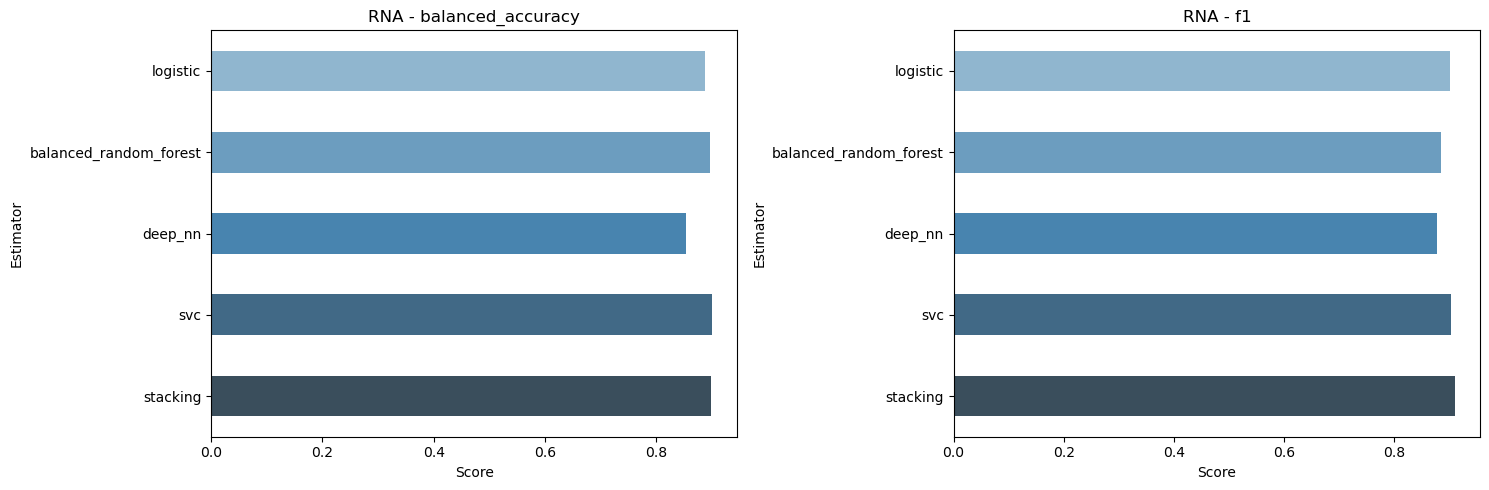

In [1236]:
plot_bar_scores(estimator_names, all_scores['rna'].values(), 'RNA', metrics=['balanced_accuracy', 'f1'])

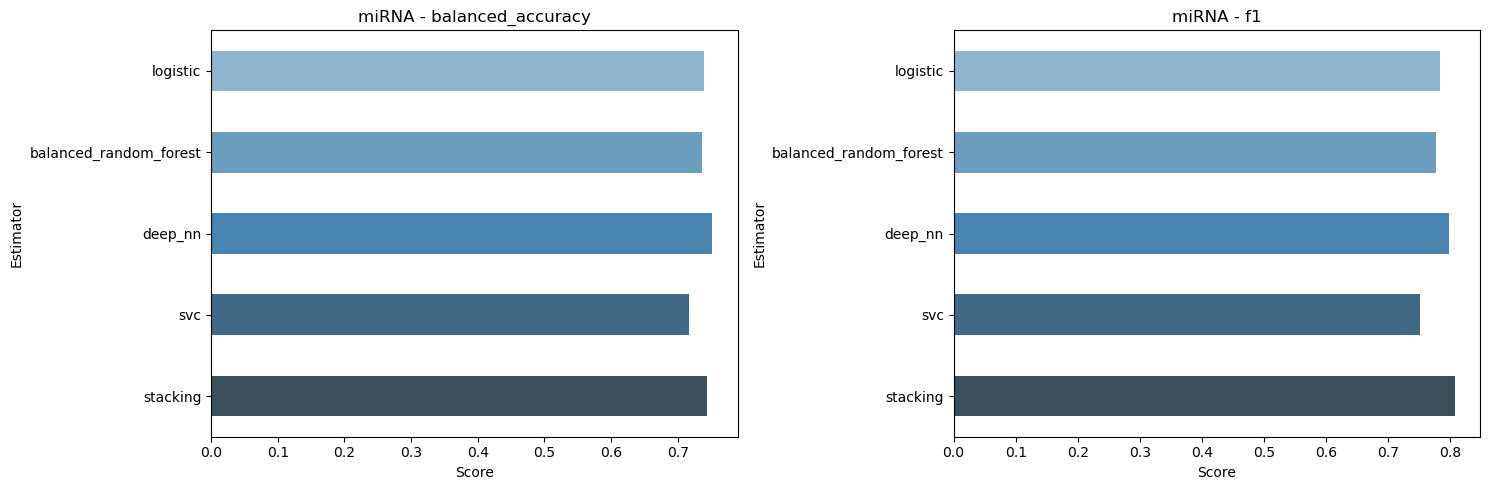

In [1237]:
plot_bar_scores(estimator_names, all_scores['mirna'].values(), 'miRNA', metrics=['balanced_accuracy', 'f1'])

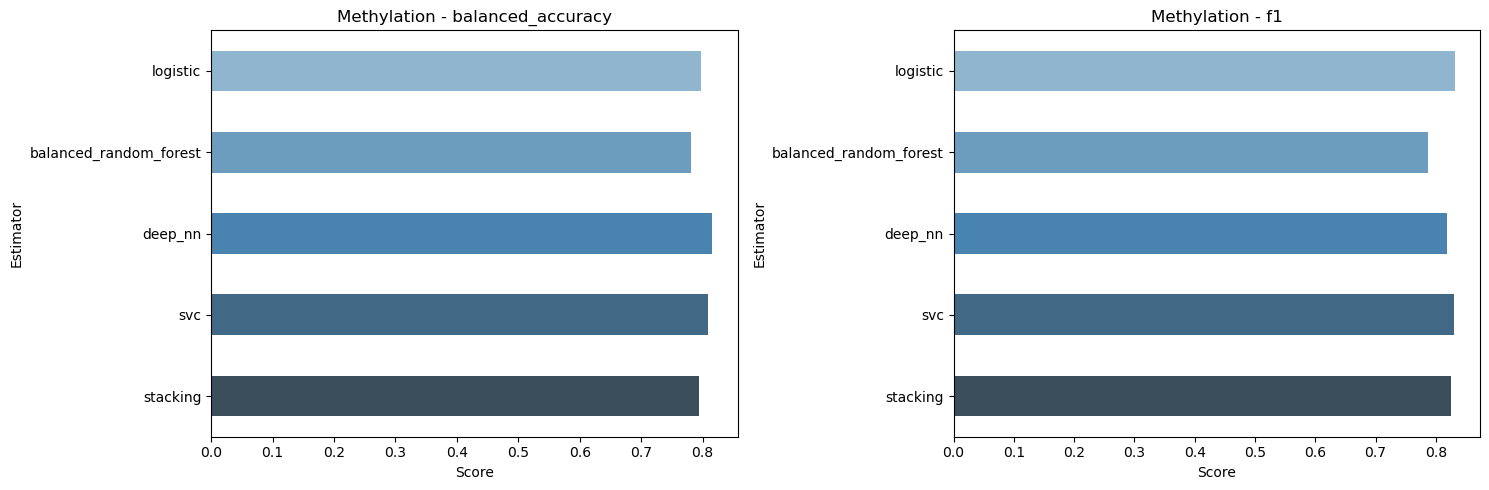

In [1240]:
plot_bar_scores(estimator_names, all_scores['meth'].values(), 'Methylation', metrics=['balanced_accuracy', 'f1'])

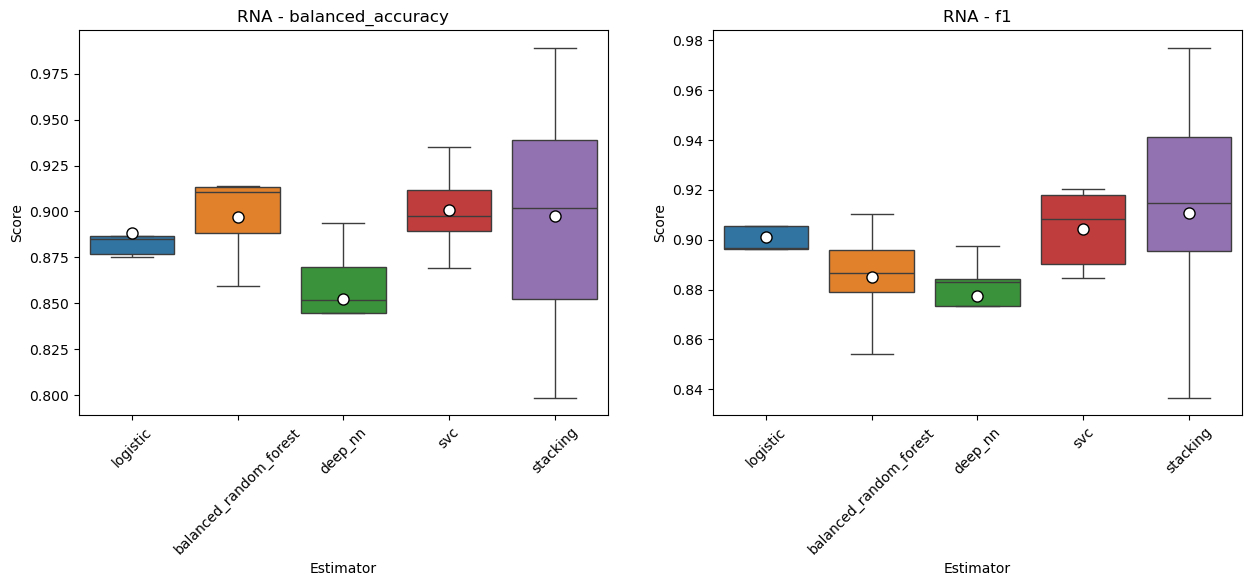

In [1241]:
plot_box_scores(estimator_names, all_scores['rna'].values(), 'RNA', metrics=['balanced_accuracy', 'f1'])

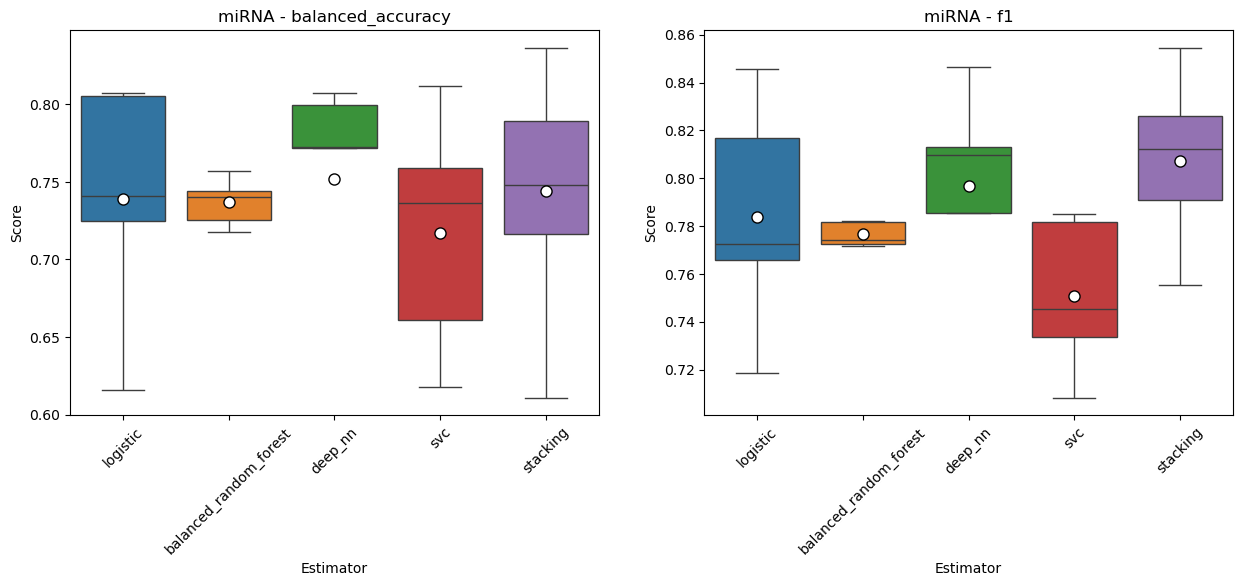

In [1244]:
plot_box_scores(estimator_names, all_scores['mirna'].values(), 'miRNA', metrics=['balanced_accuracy', 'f1'])

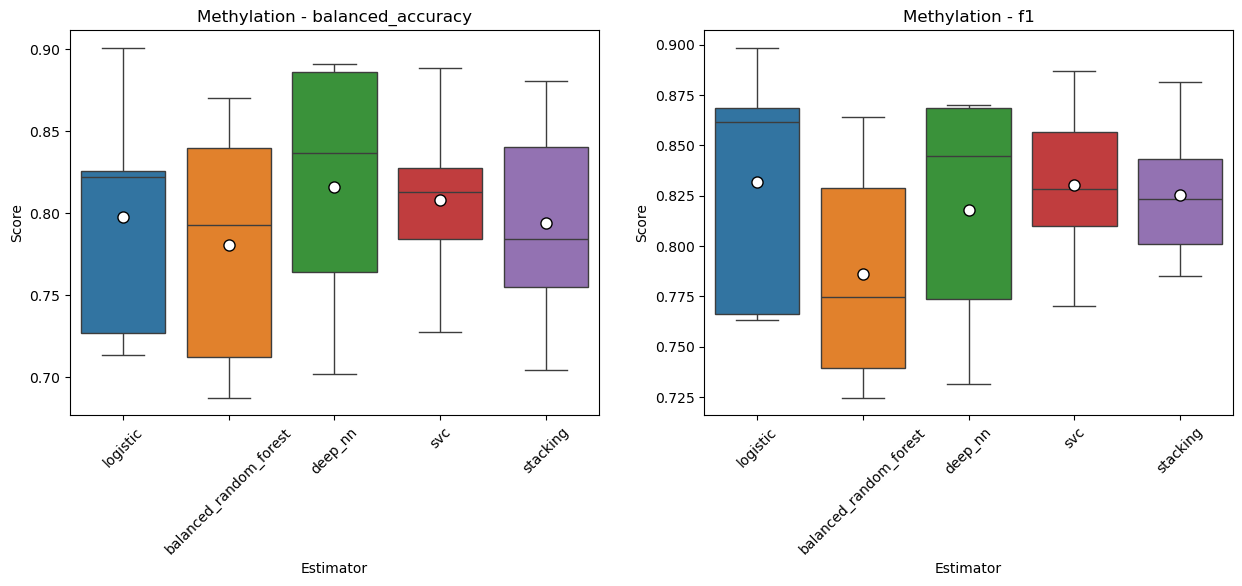

In [1245]:
plot_box_scores(estimator_names, all_scores['meth'].values(), 'Methylation', metrics=['balanced_accuracy', 'f1'])

In [1247]:
# Balanced random forest and standard scaler with deep neural network
display(all_metrics['rna'], all_metrics['mirna'], all_metrics['meth'])

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.902 +/- 0.016,0.888 +/- 0.015,0.901 +/- 0.017,0.972 +/- 0.034,0.867 +/- 0.067,0.943 +/- 0.022,0.770 +/- 0.098
balanced_random_forest,0.881 +/- 0.020,0.897 +/- 0.021,0.885 +/- 0.019,0.958 +/- 0.034,0.900 +/- 0.082,0.860 +/- 0.033,0.870 +/- 0.051
deep_nn,0.879 +/- 0.016,0.853 +/- 0.030,0.877 +/- 0.016,0.972 +/- 0.034,0.767 +/- 0.133,0.921 +/- 0.040,0.750 +/- 0.114
svc,0.905 +/- 0.014,0.901 +/- 0.022,0.904 +/- 0.014,0.972 +/- 0.034,0.900 +/- 0.082,0.930 +/- 0.032,0.800 +/- 0.084
rna,0.912 +/- 0.040,0.897 +/- 0.055,0.911 +/- 0.041,0.972 +/- 0.043,0.867 +/- 0.152,0.944 +/- 0.055,0.807 +/- 0.117


,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.788 +/- 0.040,0.739 +/- 0.070,0.784 +/- 0.044,0.959 +/- 0.054,0.567 +/- 0.200,0.860 +/- 0.035,0.570 +/- 0.112
balanced_random_forest,0.774 +/- 0.006,0.737 +/- 0.014,0.777 +/- 0.005,0.945 +/- 0.050,0.533 +/- 0.125,0.799 +/- 0.053,0.670 +/- 0.121
deep_nn,0.800 +/- 0.034,0.752 +/- 0.073,0.797 +/- 0.039,0.945 +/- 0.050,0.600 +/- 0.226,0.873 +/- 0.046,0.590 +/- 0.107
svc,0.756 +/- 0.029,0.717 +/- 0.069,0.751 +/- 0.029,0.945 +/- 0.050,0.600 +/- 0.309,0.834 +/- 0.035,0.490 +/- 0.066
mirna,0.814 +/- 0.031,0.744 +/- 0.057,0.807 +/- 0.032,0.958 +/- 0.063,0.522 +/- 0.191,0.904 +/- 0.039,0.593 +/- 0.075


,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
logistic,0.835 +/- 0.052,0.798 +/- 0.069,0.832 +/- 0.056,0.958 +/- 0.034,0.667 +/- 0.105,0.886 +/- 0.037,0.680 +/- 0.172
balanced_random_forest,0.784 +/- 0.051,0.781 +/- 0.071,0.786 +/- 0.053,0.972 +/- 0.034,0.700 +/- 0.194,0.790 +/- 0.048,0.660 +/- 0.116
deep_nn,0.823 +/- 0.051,0.816 +/- 0.073,0.818 +/- 0.055,0.958 +/- 0.034,0.833 +/- 0.149,0.882 +/- 0.061,0.590 +/- 0.150
svc,0.830 +/- 0.040,0.808 +/- 0.053,0.830 +/- 0.040,0.972 +/- 0.034,0.700 +/- 0.125,0.860 +/- 0.049,0.700 +/- 0.084
meth,0.830 +/- 0.028,0.794 +/- 0.052,0.825 +/- 0.029,0.967 +/- 0.044,0.700 +/- 0.194,0.902 +/- 0.038,0.607 +/- 0.081


In [1249]:
# Picking models we want to compare performances for
compare = [
    ('rna', 'stacking', 'logistic'),
    ('mirna', 'stacking', 'svc'),
    ('meth', 'logistic', 'stacking')
]

In [1251]:
from scipy.stats import wilcoxon

wilcoxen_results = {}
metrics = ['balanced_accuracy', 'f1']

for metric in metrics:
    wilcoxen_results[metric] = pd.DataFrame()
    for modality, est1, est2 in compare:
        df = wilcoxen_test(est1, est2, all_scores[modality][est1]['test_' + metric], all_scores[modality][est2]['test_' + metric])
        wilcoxen_results[metric] = pd.concat([wilcoxen_results[metric], df])


ValueError: operands could not be broadcast together with shapes (15,) (5,) 

In [ ]:
display(wilcoxen_results['balanced_accuracy'], wilcoxen_results['f1'])

## Multi Omics Integration Ensemble

### Ensemble Model as a Custom Classifier

In [1254]:
column_names = {}

for key in X.keys():
    column_names[key] = X[key].columns

In [1255]:
meta_ensembles = {}
meta_ensembles['rna + mirna + meth'] = MultiOmicsIntegrationClassifier(classifiers, cv=3)
meta_ensembles['mirna + meth'] = MultiOmicsIntegrationClassifier({key: classifiers[key] for key in ['mirna', 'meth']}, cv=3)
meta_ensembles['rna + mirna'] = MultiOmicsIntegrationClassifier({key: classifiers[key] for key in ['rna', 'mirna']}, cv=3)
meta_ensembles['rna + meth'] = MultiOmicsIntegrationClassifier({key: classifiers[key] for key in ['rna', 'meth']}, cv=3)

In [1258]:
X_merged = {}
X_merged['rna + mirna + meth'] = pd.concat([X['rna'], X['mirna'], X['meth']], axis=1, join='inner')
X_merged['mirna + meth'] = pd.concat([X['mirna'], X['meth']], axis=1, join='inner')
X_merged['rna + mirna'] = pd.concat([X['rna'], X['mirna']], axis=1, join='inner')
X_merged['rna + meth'] = pd.concat([X['rna'], X['meth']], axis=1, join='inner')


In [1259]:
integration_scores = {}
integration_metrics = {}

In [1262]:
integration_scores['rna + mirna + meth'], integration_metrics['rna + mirna + meth'] = get_cross_metrics(meta_ensembles['rna + mirna + meth'], X_merged['rna + mirna + meth'], y, name='rna + mirna + meth', cv=5, scoring=brca_scoring, fit_params={'column_names': column_names})

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_i

In [1368]:
integration_metrics['rna + mirna + meth']

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
rna + mirna + meth,0.895 +/- 0.019,0.889 +/- 0.027,0.894 +/- 0.021,0.972 +/- 0.034,0.900 +/- 0.082,0.934 +/- 0.019,0.750 +/- 0.077


In [1264]:
integration_scores['mirna + meth'], integration_metrics['mirna + meth'] = get_cross_metrics(meta_ensembles['mirna + meth'], X_merged['mirna + meth'], y, name='mirna + meth', cv=5, verbose=2, scoring=brca_scoring, fit_params={'column_names': {key: column_names[key] for key in ['mirna', 'meth']}})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/

In [1376]:
integration_metrics['mirna + meth']

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
mirna + meth,0.837 +/- 0.019,0.804 +/- 0.025,0.834 +/- 0.020,0.959 +/- 0.054,0.700 +/- 0.125,0.895 +/- 0.069,0.660 +/- 0.132


In [1265]:
integration_scores['rna + mirna'], integration_metrics['rna + mirna'] = get_cross_metrics(meta_ensembles['rna + mirna'], X_merged['rna + mirna'], y, name='rna + mirna', cv=5, verbose=2, scoring=brca_scoring, fit_params={'column_names': {key: column_names[key] for key in ['rna', 'mirna']}})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/

In [1374]:
integration_metrics['rna + mirna']

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
rna + mirna,0.902 +/- 0.022,0.889 +/- 0.020,0.902 +/- 0.022,0.972 +/- 0.034,0.867 +/- 0.067,0.939 +/- 0.017,0.780 +/- 0.087


In [1266]:
integration_scores['rna + meth'], integration_metrics['rna + meth'] = get_cross_metrics(meta_ensembles['rna + meth'], X_merged['rna + meth'], y, name='rna + meth', cv=5, verbose=2, scoring=brca_scoring, fit_params={'column_names': {key: column_names[key] for key in ['rna', 'meth']}})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   14.2s remaining:   21.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   14.3s finished


In [1370]:
integration_metrics['rna + meth']

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
rna + meth,0.907 +/- 0.016,0.900 +/- 0.026,0.906 +/- 0.019,0.972 +/- 0.034,0.900 +/- 0.082,0.939 +/- 0.021,0.790 +/- 0.097


In [1267]:
all_integration_metrics = pd.concat([modality_metrics, pd.concat([x for x in integration_metrics.values()])])
names = ['rna', 'mirna', 'meth', 'rna + mirna + meth', 'mirna + meth', 'rna + mirna', 'rna + meth']

all_integration_scores = scores

# Adding multi-omic ensemble scores
for name, value in integration_scores.items():
    all_integration_scores[name] = value

In [1268]:
all_integration_metrics

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
rna,0.912 +/- 0.040,0.897 +/- 0.055,0.911 +/- 0.041,0.972 +/- 0.043,0.867 +/- 0.152,0.944 +/- 0.055,0.807 +/- 0.117
mirna,0.814 +/- 0.031,0.744 +/- 0.057,0.807 +/- 0.032,0.958 +/- 0.063,0.522 +/- 0.191,0.904 +/- 0.039,0.593 +/- 0.075
meth,0.830 +/- 0.028,0.794 +/- 0.052,0.825 +/- 0.029,0.967 +/- 0.044,0.700 +/- 0.194,0.902 +/- 0.038,0.607 +/- 0.081
rna + mirna + meth,0.895 +/- 0.019,0.889 +/- 0.027,0.894 +/- 0.021,0.972 +/- 0.034,0.900 +/- 0.082,0.934 +/- 0.019,0.750 +/- 0.077
mirna + meth,0.837 +/- 0.019,0.804 +/- 0.025,0.834 +/- 0.020,0.959 +/- 0.054,0.700 +/- 0.125,0.895 +/- 0.069,0.660 +/- 0.132
rna + mirna,0.902 +/- 0.022,0.889 +/- 0.020,0.902 +/- 0.022,0.972 +/- 0.034,0.867 +/- 0.067,0.939 +/- 0.017,0.780 +/- 0.087
rna + meth,0.907 +/- 0.016,0.900 +/- 0.026,0.906 +/- 0.019,0.972 +/- 0.034,0.900 +/- 0.082,0.939 +/- 0.021,0.790 +/- 0.097


In [1276]:
# Convert and write JSON object to file
with open("notebooks_new/results/brca/brca_multi_omics_results.json", "w") as outfile:
    json.dump(integration_scores, outfile, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

In [1278]:
# Convert and write JSON object to file
with open("notebooks_new/results/brca/brca_modality_multi_omics_results.json", "w") as outfile:
    json.dump(all_integration_scores, outfile, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

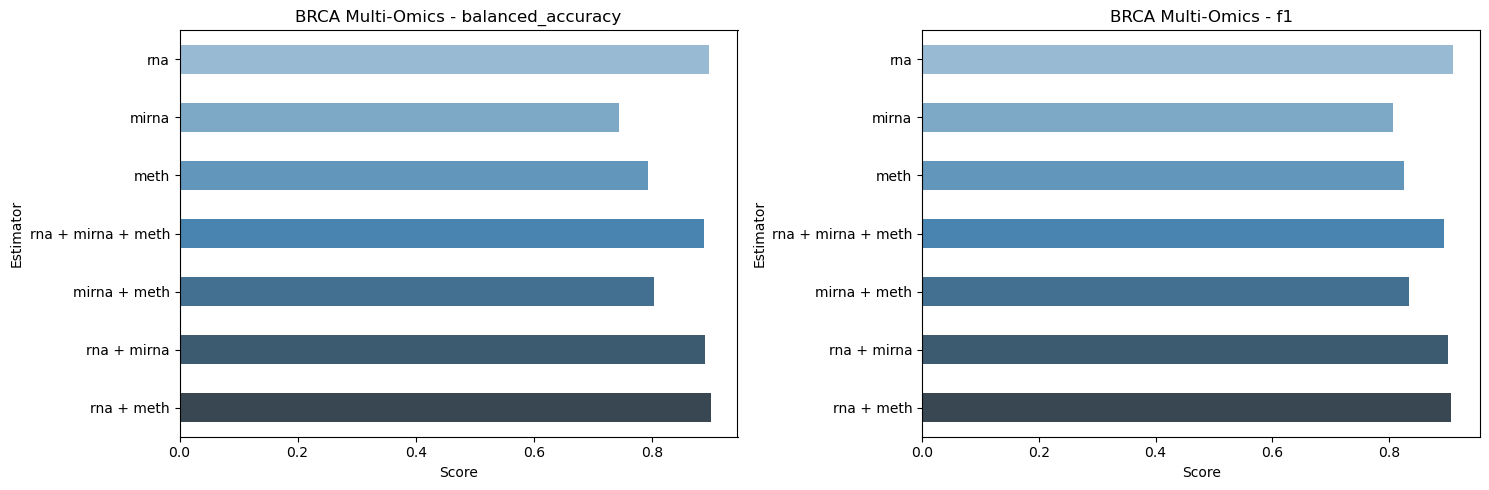

In [1280]:
plot_bar_scores(names, all_integration_scores.values(), 'BRCA Multi-Omics', metrics=['balanced_accuracy', 'f1'])

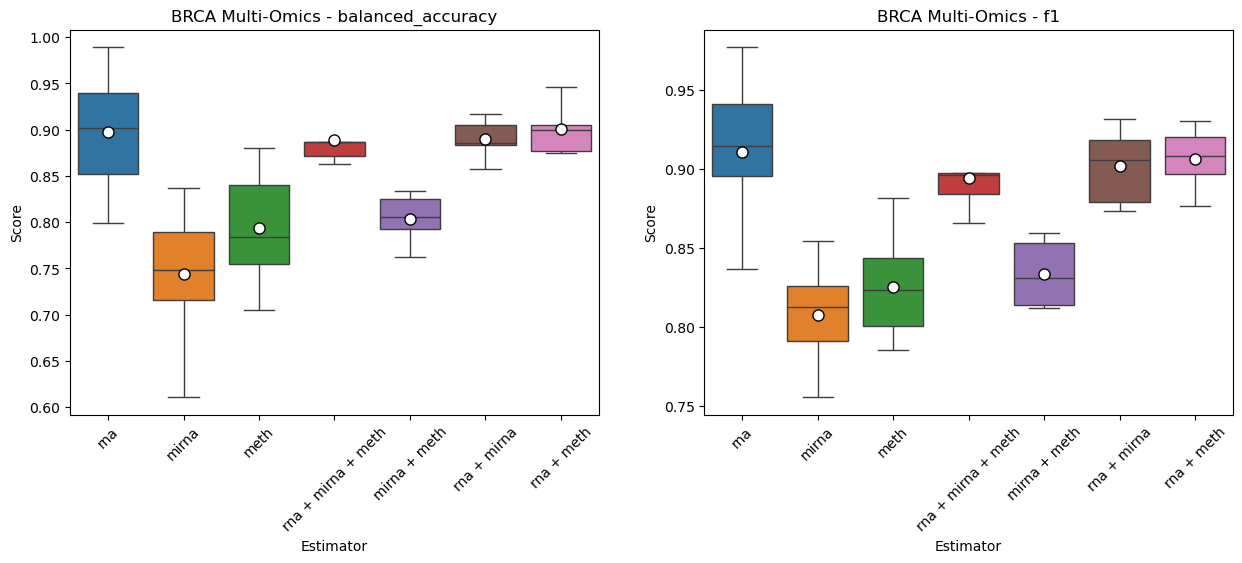

In [1281]:
plot_box_scores(names, all_integration_scores.values(), 'BRCA Multi-Omics', metrics=['balanced_accuracy', 'f1'])

## Statistical Significance

Now that we see the results, we want to check if the performance differences between our multi-omics ensemble models and the modality ensemble models are significant. We can employ the Wilcoxen test, using multiple replications of cross-validation to get scores.

### Wilcoxen

In [1287]:
ensemble_results = {}
ensemble_metrics = {}

In [1289]:
def wilcoxen_test(name_1, name_2, scores_1, scores_2):

    stat, p = wilcoxon(scores_1, scores_2, alternative='greater')

    df = pd.Series({'estimator_1': name_1, 'estimator_2': name_2, 'statistic': stat, 'p': p, 'significant': p <= 0.05})

    return pd.DataFrame(df).T

In [1291]:
ensemble_results['rna'], ensemble_metrics['rna'] = get_cross_metrics(classifiers['rna'], X['rna'], y, name='rna', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring)

In [1292]:
ensemble_results['mirna'], ensemble_metrics['mirna'] = get_cross_metrics(classifiers['mirna'], X['mirna'], y, name='mirna', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_i

In [1293]:
ensemble_results['meth'], ensemble_metrics['meth'] = get_cross_metrics(classifiers['meth'], X['meth'], y, name='meth', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring)

In [1294]:
ensemble_results['rna + mirna'], ensemble_metrics['rna + mirna'] = get_cross_metrics(meta_ensembles['rna + mirna'], X_merged['rna + mirna'], y, name='rna + mirna', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring, fit_params={'column_names': {key: column_names[key] for key in ['rna', 'mirna']}})

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_i

In [1295]:
ensemble_results['rna + meth'], ensemble_metrics['rna + meth'] = get_cross_metrics(meta_ensembles['rna + meth'], X_merged['rna + meth'], y, name='rna + meth', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring, fit_params={'column_names': {key: column_names[key] for key in ['rna', 'meth']}})

In [1298]:
ensemble_results['mirna + meth'], ensemble_metrics['mirna + meth'] = get_cross_metrics(meta_ensembles['mirna + meth'], X_merged['mirna + meth'], y, name='mirna + meth', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring, fit_params={'column_names': {key: column_names[key] for key in ['mirna', 'meth']}})

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_i

In [1299]:
ensemble_results['rna + mirna + meth'], ensemble_metrics['rna + mirna + meth'] = get_cross_metrics(meta_ensembles['rna + mirna + meth'], X_merged['rna + mirna + meth'], y, name='rna + mirna + meth', cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1), scoring=brca_scoring, fit_params={'column_names': column_names})

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_i

In [1300]:
# Picking models we want to compare performances for
compare = [
    ('mirna + meth', 'meth'),
    ('rna + mirna + meth', 'rna'),
    ('rna + meth', 'rna'),
    ('rna + mirna', 'rna'),
    ('rna + mirna + meth', 'mirna'),
    ('rna + meth', 'meth'),
    ('rna + mirna', 'mirna')
]

In [1305]:

wilcoxen_results = {}
metrics = ['balanced_accuracy', 'f1']

for metric in metrics:
    wilcoxen_results[metric] = pd.DataFrame()
    for est1, est2 in compare:
        df = wilcoxen_test(est1, est2, ensemble_results[est1]['test_' + metric], ensemble_results[est2]['test_' + metric])
        wilcoxen_results[metric] = pd.concat([wilcoxen_results[metric], df])


In [1306]:
display(wilcoxen_results['balanced_accuracy'], wilcoxen_results['f1'])

,estimator_1,estimator_2,statistic,p,significant
0,mirna + meth,meth,68.5,0.339386,False
0,rna + mirna + meth,rna,26.0,0.913785,False
0,rna + meth,rna,8.0,0.976573,False
0,rna + mirna,rna,45.0,0.805298,False
0,rna + mirna + meth,mirna,120.0,0.000031,True
0,rna + meth,meth,119.0,0.000061,True
0,rna + mirna,mirna,120.0,0.000031,True


,estimator_1,estimator_2,statistic,p,significant
0,mirna + meth,meth,89.0,0.053497,False
0,rna + mirna + meth,rna,35.0,0.768464,False
0,rna + meth,rna,9.0,0.970332,False
0,rna + mirna,rna,50.0,0.719299,False
0,rna + mirna + meth,mirna,120.0,0.000031,True
0,rna + meth,meth,119.0,0.000061,True
0,rna + mirna,mirna,120.0,0.000031,True


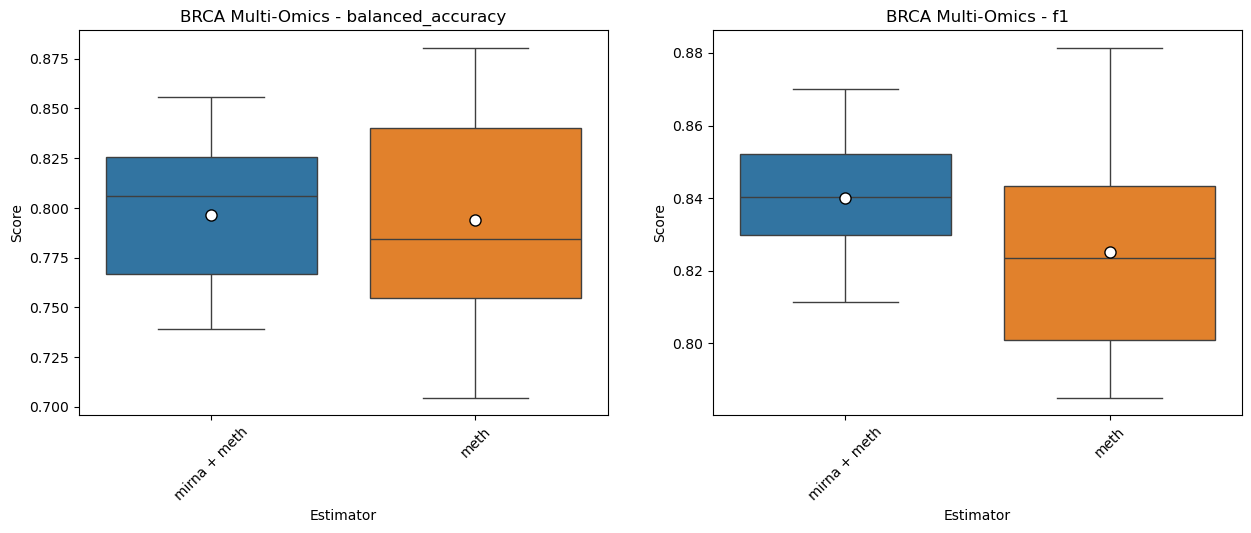

In [1307]:
plot_box_scores(['mirna + meth', 'meth'], [ensemble_results['mirna + meth'], ensemble_results['meth']], 'BRCA Multi-Omics', metrics=['balanced_accuracy', 'f1'])

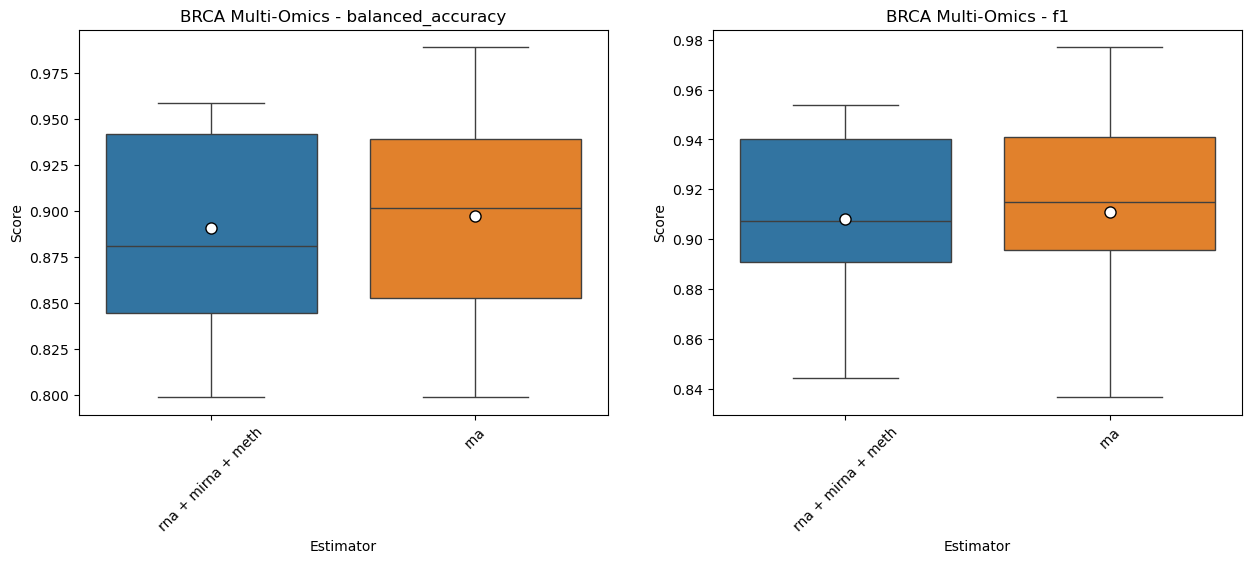

In [1308]:
plot_box_scores(['rna + mirna + meth', 'rna'], [ensemble_results['rna + mirna + meth'], ensemble_results['rna']], 'BRCA Multi-Omics', metrics=['balanced_accuracy', 'f1'])

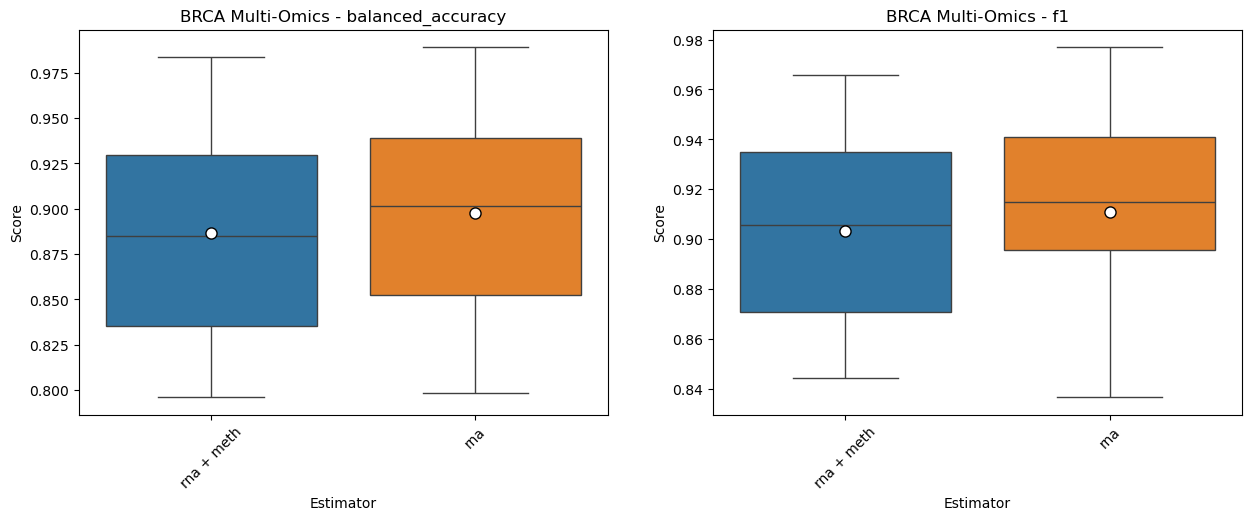

In [1309]:
plot_box_scores(['rna + meth', 'rna'], [ensemble_results['rna + meth'], ensemble_results['rna']], 'BRCA Multi-Omics', metrics=['balanced_accuracy', 'f1'])

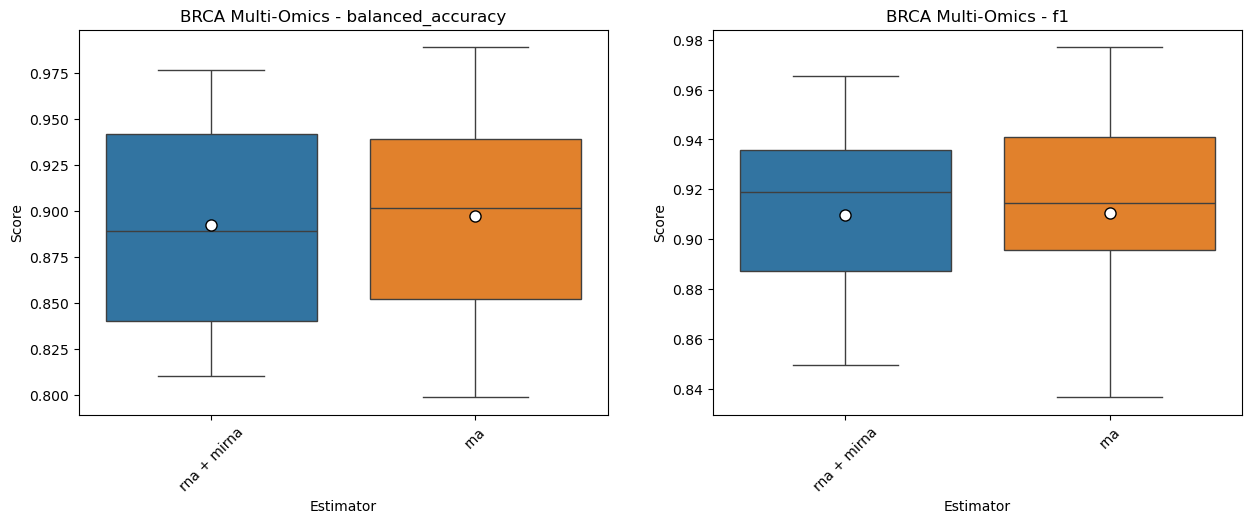

In [1310]:
plot_box_scores(['rna + mirna', 'rna'], [ensemble_results['rna + mirna'], ensemble_results['rna']], 'BRCA Multi-Omics', metrics=['balanced_accuracy', 'f1'])

In [1319]:
import json

In [1321]:
"""
# Run this if continuing an already saved run:
with open("notebooks_new/results/brca/brca_5x3_results.json",'r+') as file:
    ensemble_results_2 = json.load(file)
    ensemble_metrics_2 = pd.DataFrame()

    for model in ensemble_results_2:
      metrics = {}

      for scorer in brca_scoring:
        metrics[scorer] = []

      for scorer in brca_scoring:
          metrics[scorer].append(
              "%0.3f +/- %0.3f"
              % (np.mean(ensemble_results_2[model]["test_%s" % scorer]), np.std(ensemble_results_2[model]["test_%s" % scorer]))
      )
      ensemble_metrics_2 = pd.concat([ensemble_metrics_2, pd.DataFrame(metrics, index=[model])])
"""

'\n# Run this if continuing an already saved run:\nwith open("notebooks_new/results/brca/brca_5x3_results.json",\'r+\') as file:\n    ensemble_results_2 = json.load(file)\n    ensemble_metrics_2 = pd.DataFrame()\n\n    for model in ensemble_results_2:\n      metrics = {}\n\n      for scorer in brca_scoring:\n        metrics[scorer] = []\n\n      for scorer in brca_scoring:\n          metrics[scorer].append(\n              "%0.3f +/- %0.3f"\n              % (np.mean(ensemble_results_2[model]["test_%s" % scorer]), np.std(ensemble_results_2[model]["test_%s" % scorer]))\n      )\n      ensemble_metrics_2 = pd.concat([ensemble_metrics_2, pd.DataFrame(metrics, index=[model])])\n'

In [1323]:
#ensemble_metrics_2

In [1325]:
"""
integration_results = {}
integration_results['rna'] = ensemble_results_2['rna']
integration_results['mirna'] = ensemble_results_2['mirna']
integration_results['meth'] = ensemble_results_2['meth']
integration_results['rna + mirna'] = ensemble_results_2['rna + mirna']
integration_results['rna + meth'] = ensemble_results_2['rna + meth']
integration_results['mirna + meth'] = ensemble_results_2['mirna + meth']
integration_results['rna + mirna + meth'] = ensemble_results_2['rna + mirna + meth']
"""

"\nintegration_results = {}\nintegration_results['rna'] = ensemble_results_2['rna']\nintegration_results['mirna'] = ensemble_results_2['mirna']\nintegration_results['meth'] = ensemble_results_2['meth']\nintegration_results['rna + mirna'] = ensemble_results_2['rna + mirna']\nintegration_results['rna + meth'] = ensemble_results_2['rna + meth']\nintegration_results['mirna + meth'] = ensemble_results_2['mirna + meth']\nintegration_results['rna + mirna + meth'] = ensemble_results_2['rna + mirna + meth']\n"

In [1327]:
"""
integration_metrics = pd.DataFrame()

for model in integration_results:
      metrics = {}

      for scorer in brca_scoring:
        metrics[scorer] = []

      for scorer in brca_scoring:
          metrics[scorer].append(
              "%0.3f +/- %0.3f"
              % (np.mean(integration_results[model]["test_%s" % scorer]), np.std(integration_results[model]["test_%s" % scorer]))
      )
      integration_metrics = pd.concat([integration_metrics, pd.DataFrame(metrics, index=[model])])
"""

'\nintegration_metrics = pd.DataFrame()\n\nfor model in integration_results:\n      metrics = {}\n\n      for scorer in brca_scoring:\n        metrics[scorer] = []\n\n      for scorer in brca_scoring:\n          metrics[scorer].append(\n              "%0.3f +/- %0.3f"\n              % (np.mean(integration_results[model]["test_%s" % scorer]), np.std(integration_results[model]["test_%s" % scorer]))\n      )\n      integration_metrics = pd.concat([integration_metrics, pd.DataFrame(metrics, index=[model])])\n'

In [1328]:
#integration_metrics

In [1331]:
#names = ['rna', 'mirna', 'meth', 'rna + mirna', 'rna + meth', 'mirna + meth', 'rna + mirna + meth']

In [1333]:
#plot_bar_scores(names, integration_results.values(), 'BRCA Subtyping Multi-Omics', metrics=['balanced_accuracy', 'f1'])

In [1335]:
#plot_box_scores(names, integration_results.values(), 'BRCA Subtyping Multi-Omics', metrics=['balanced_accuracy', 'f1'])

In [1337]:
"""
import json
# Convert and write JSON object to file
with open("notebooks_new/results/brca/brca_5x3_results_final.json", "w") as outfile:
    json.dump(integration_results, outfile, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

"""

'\nimport json\n# Convert and write JSON object to file\nwith open("notebooks_new/results/brca/brca_5x3_results_final.json", "w") as outfile:\n    json.dump(integration_results, outfile, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)\n\n'

## Feature Importance

In [1340]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

In [1342]:
# Splitting into training, validation
X_train, X_test, y_train, y_test = train_test_split(X_merged['rna + mirna + meth'], y, random_state=0, stratify=y)

In [1344]:
# Fitting on training data
meta_ensembles['rna + mirna + meth'].fit(X_train, y_train, column_names)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated

MultiOmicsIntegrationClassifier(cv=3,
                                estimator_dict={'meth': ModalityPipeline(cv=3,
                                                                         estimator_list=[('logistic',
                                                                                          Pipeline(steps=[('standardscaler',
                                                                                                           StandardScaler()),
                                                                                                          ('logisticregression',
                                                                                                           LogisticRegression(max_iter=1000,
                                                                                                                              n_jobs=-1,
                                                                                                                              random_state=0))])),
                                                                                         ('balanced_random_forest',
                                                                                          Pipeline(steps=[('standardscaler',
                                                                                                           StandardScaler()),
                                                                                                          ('balancedrandomforestcla...
                                                                                                          BalancedRandomForestClassifier(bootstrap=False,
                                                                                                                                         n_jobs=-1,
                                                                                                                                         random_state=0,
                                                                                                                                         replacement=True,
                                                                                                                                         sampling_strategy='all'))])),
                                                                                        ('deep_nn',
                                                                                         Pipeline(steps=[('standardscaler',
                                                                                                          StandardScaler()),
                                                                                                         ('mlpclassifier',
                                                                                                          MLPClassifier(random_state=0))])),
                                                                                        ('svc',
                                                                                         Pipeline(steps=[('standardscaler',
                                                                                                          StandardScaler()),
                                                                                                         ('svc',
                                                                                                          SVC(kernel='linear',
                                                                                                              max_iter=1000,
                                                                                                              random_state=0))]))])})

In [1345]:
# Getting baseline scores
baseline_scores = {}
for name, scorer in brca_scoring.items():
  baseline_scores[name] = get_scorer(scorer)(meta_ensembles['rna + mirna + meth'], X_test, y_test)

In [1346]:
pd.DataFrame(baseline_scores, index=[""])

,accuracy,balanced_accuracy,f1,recall (Basal),recall (Her2),recall (LumA),recall (LumB)
,0.944444,0.962456,0.94516,1.0,1.0,0.929825,0.92


In [1347]:
result = permutation_importance(meta_ensembles['rna + mirna + meth'], X_test, y_test, n_repeats=10, random_state=0, scoring=brca_scoring, n_jobs=-1)

In [1348]:
sorted_importances_idx = result['balanced_accuracy'].importances_mean.argsort()
importances = pd.DataFrame(
    result['balanced_accuracy'].importances[sorted_importances_idx].T,
    columns=X_merged['rna + mirna + meth'].columns[sorted_importances_idx],
)

importances.head()

,DEFB123_rna,ADPRH_meth,CCDC65_meth,hsa-mir-124-2_mirna,SH3BGRL_rna,SH2D4A_rna,SGK3_rna,SGCD_rna,SFTA3_rna,SFRP4_rna,...,NME3_rna,ADAMTS1_rna,EPS8L1_rna,SYT8_rna,AGT_rna,SEMA3E_rna,SOCS2_rna,RAMP3_rna,FAAH_rna,hsa-mir-2115_mirna
0,-0.004386,0.000000,-0.004386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.01,0.010000,0.01,0.024386,0.01,0.02,0.020000,0.010000,0.03125
1,-0.004386,0.000000,-0.004386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.02,0.02,0.014386,0.02,0.010000,0.01,0.02,0.024386,0.010000,0.03125
2,0.000000,-0.004386,0.004386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.02,0.00,0.010000,0.01,0.004386,0.01,0.00,0.010000,0.020000,0.00000
3,-0.004386,0.000000,0.004386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.01,0.02,0.014386,0.02,0.010000,0.02,0.02,0.014386,0.014386,0.03125
4,-0.004386,0.000000,0.004386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.02,0.01,0.014386,0.01,0.014386,0.01,0.01,0.010000,0.020000,0.04125


In [1349]:
importances.iloc[:, -20:].columns

Index(['hsa-mir-133a-1_mirna', 'CBLN2_rna', 'FGFR4_rna', 'KCNK5_rna',
       'DOK7_rna', 'CKB_rna', 'ATF3_rna', 'GRIK1_rna', 'SLC39A8_rna',
       'FAM189A2_rna', 'NME3_rna', 'ADAMTS1_rna', 'EPS8L1_rna', 'SYT8_rna',
       'AGT_rna', 'SEMA3E_rna', 'SOCS2_rna', 'RAMP3_rna', 'FAAH_rna',
       'hsa-mir-2115_mirna'],
      dtype='object')

Text(0, 0.5, 'Genes')

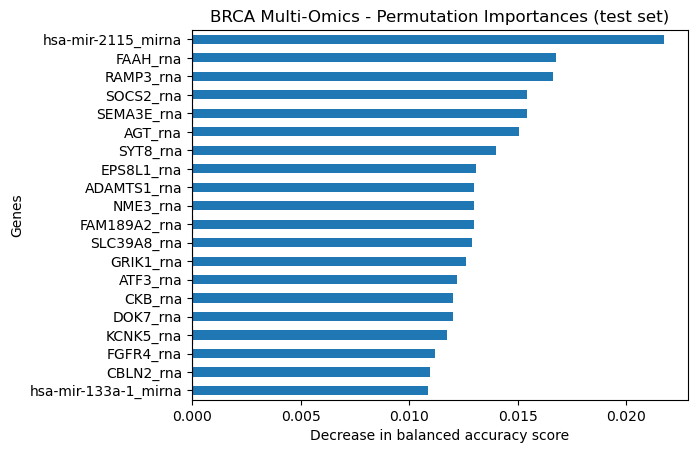

In [1350]:
# Printing top 20 important features
ax = importances.mean()[-20:].plot(kind='barh')
ax.set_title("BRCA Multi-Omics - Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in balanced accuracy score")
ax.set_ylabel('Genes')

In [1354]:
top_genes = []

for i in result['balanced_accuracy'].importances_mean.argsort()[::-1]:
     if result['balanced_accuracy'].importances_mean[i] > 0:
        top_genes.append(X_merged['rna + mirna + meth'].columns[i])
        print(f"{X_merged['rna + mirna + meth'].columns[i]:<8}  "
               f"{result['balanced_accuracy'].importances_mean[i]:.4f}"
               f" +/- {result['balanced_accuracy'].importances_std[i]:.4f}")

hsa-mir-2115_mirna  0.0218 +/- 0.0164
FAAH_rna  0.0168 +/- 0.0046
RAMP3_rna  0.0166 +/- 0.0050
SOCS2_rna  0.0154 +/- 0.0071
SEMA3E_rna  0.0154 +/- 0.0047
AGT_rna   0.0151 +/- 0.0067
SYT8_rna  0.0140 +/- 0.0049
EPS8L1_rna  0.0131 +/- 0.0020
ADAMTS1_rna  0.0130 +/- 0.0078
NME3_rna  0.0130 +/- 0.0078
FAM189A2_rna  0.0130 +/- 0.0078
SLC39A8_rna  0.0129 +/- 0.0086
GRIK1_rna  0.0126 +/- 0.0021
ATF3_rna  0.0122 +/- 0.0022
CKB_rna   0.0120 +/- 0.0060
DOK7_rna  0.0120 +/- 0.0040
KCNK5_rna  0.0118 +/- 0.0021
FGFR4_rna  0.0112 +/- 0.0043
CBLN2_rna  0.0109 +/- 0.0045
hsa-mir-133a-1_mirna  0.0109 +/- 0.0018
MYH11_rna  0.0109 +/- 0.0018
HOXB2_meth  0.0108 +/- 0.0029
CA2_rna   0.0104 +/- 0.0013
GLB1L2_rna  0.0104 +/- 0.0013
MIA_rna   0.0104 +/- 0.0085
LOC388692_rna  0.0104 +/- 0.0013
KLK5_rna  0.0104 +/- 0.0013
ACTG2_rna  0.0103 +/- 0.0040
hsa-mir-153-2_mirna  0.0102 +/- 0.0046
hsa-mir-429_mirna  0.0101 +/- 0.0051
ELOVL2_rna  0.0101 +/- 0.0041
hsa-mir-412_mirna  0.0101 +/- 0.0046
TFAP2B_rna  0.0100 +

In [1360]:
top_genes_modality = {}

for modality in datasets:
  top_genes_modality[modality] = []

for gene in top_genes:
  for modality in datasets:
    if ("_" + modality) in gene.lower():
      #top_genes_modality[modality].append(gene.removesuffix('_'+modality))
      top_genes_modality[modality].append(gene)
      break

In [1362]:
# Printing to copy-paste into top-gene for enrichment analysis
for modality in top_genes_modality:
  print(f"{modality}: " + ','.join(top_genes_modality[modality]))
  print("")

rna: FAAH_rna,RAMP3_rna,SOCS2_rna,SEMA3E_rna,AGT_rna,SYT8_rna,EPS8L1_rna,ADAMTS1_rna,NME3_rna,FAM189A2_rna,SLC39A8_rna,GRIK1_rna,ATF3_rna,CKB_rna,DOK7_rna,KCNK5_rna,FGFR4_rna,CBLN2_rna,MYH11_rna,CA2_rna,GLB1L2_rna,MIA_rna,LOC388692_rna,KLK5_rna,ACTG2_rna,ELOVL2_rna,TFAP2B_rna,NEUROD1_rna,KRT81_rna,FAM46B_rna,POTEC_rna,IER3_rna,ART3_rna,SLC6A4_rna,SLC38A1_rna,SFRP1_rna,SEZ6_rna,ANXA3_rna,PCSK1N_rna,RRM2_rna,TMEM196_rna,PPP1R14C_rna,COL9A3_rna,CAPS_rna,CBR1_rna,BBOX1_rna,VGLL1_rna,VSIG2_rna,VTCN1_rna,CDH3_rna,CHI3L1_rna,PCDHA12_rna,SFXN5_rna,DTL_rna,C1orf115_rna,STAC2_rna,SSFA2_rna,VSTM2A_rna,PPP1R1B_rna,CAPN9_rna,GLRA3_rna,BAIAP3_rna,TRPV6_rna,RASD1_rna,GDPD2_rna,RHOBTB3_rna,CCL18_rna,S100A8_rna,CDC20_rna,S100A9_rna,CDCP1_rna,CSDA_rna,SPAG16_rna,FNDC1_rna,FAIM2_rna,CYP2A7_rna,C1orf116_rna,FGF10_rna,SLFN5_rna,FAM38B_rna,SLC6A14_rna,SLC9A2_rna,CDH7_rna,SNCG_rna,JUNB_rna,KLK6_rna,IRX4_rna,LOC152225_rna,P2RY11_rna,ADCY1_rna,ACTN2_rna,MGP_rna,OAS3_rna,MFAP5_rna,NDST4_rna,KLK7_rna,PER1_rna,KP

In [1364]:
# Convert and write csv object to file
with open("notebooks_new/results/brca/permutation_results.csv", "w") as outfile:
    importances.to_csv(outfile)

In [1280]:
with open("notebooks_new/results/brca/marker_genes.json", "w") as outfile:
    json.dump(top_genes_modality, outfile, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)